# Aula Prática: Processos de Decisão de Markov (MDPs) e Programação Dinâmica

Nesta aula, vamos modelar um problema de tomada de decisão sequencial usando Processos de Decisão de Markov (MDPs). Em ambientes estocásticos, as ações são incertas e o resultado de uma decisão hoje impacta as opções de amanhã.

## 1. O Ambiente: GridWorld
Para estudar esses problemas, usaremos um ambiente chamado Gridworld. Imagine um robô navegando em uma grade com as seguintes regras:
* **Ações ($A$):** O robô pode mover-se em 4 direções: Norte (↑), Sul (↓), Leste (→), Oeste (←).
* **Transições Estocásticas ($P(s'|s,a)$):** Há incerteza no movimento. Existe 80% de chance de ir na direção desejada e 10% para cada lado perpendicular.
* **Recompensas ($R$):** Custo de "viver" no grid é de -0.04 por passo (incentiva encontrar a saída). O objetivo é alcançar o estado terminal $+1$ evitando o estado $-1$.
* **Fator de Desconto ($\gamma$):** Determina a preferência por recompensas imediatas.

INFORMAÇÕES DO GRIDWORLD
Dimensões: 3 linhas x 4 colunas
Total de estados: 11
Paredes: 1
Estados terminais: 2
Fator de desconto (γ): 0.9
Ruído: 0.2
Living reward: -0.04
Ações disponíveis: ['N', 'S', 'L', 'O']

Paredes: [(1, 1)]

Estados terminais:
  (0, 3): reward = 1.0
  (1, 3): reward = -1.0


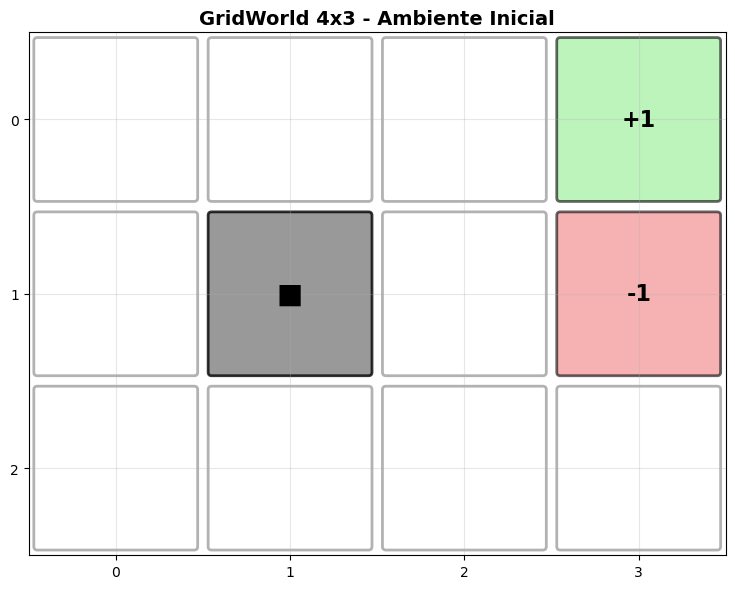

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Importando os módulos desenvolvidos para a disciplina
from environment import create_classic_gridworld, print_gridworld_info
from algorithms import iter_policy_eval, value_iteration, policy_iteration
from visualization import visualize_gridworld

# Inicializando o ambiente GridWorld
gw = create_classic_gridworld()

# Exibindo as propriedades do MDP
print_gridworld_info(gw)

# Visualizando a geografia do ambiente
visualize_gridworld(gw, title="GridWorld 4x3 - Ambiente Inicial")
plt.show()

Você pode verificar a documentação das funções carregadas por exemplo:

In [25]:
help(create_classic_gridworld)

Help on function create_classic_gridworld in module environment:

create_classic_gridworld() -> environment.GridWorld
    Cria o GridWorld 4x3 clássico do Russell & Norvig.
    
    Layout:
    -------
    [ ] [ ] [ ] [+1]
    [ ] [■] [ ] [-1]
    [S] [ ] [ ] [ ]
    
    Legenda:
    --------
    S  : Estado inicial típico (2,0)
    ■  : Parede em (1,1)
    +1 : Terminal positivo em (0,3)
    -1 : Terminal negativo em (1,3)
    
    Configuração:
    -------------
    - Tamanho: 3 linhas x 4 colunas
    - Fator de desconto: γ = 0.9
    - Ruído: 20% (0.2)
    - Living reward: -0.04
    
    Retorna:
    --------
    GridWorld
        Ambiente configurado
    
    Exemplo:
    --------
    >>> gw = create_classic_gridworld()
    >>> print(f"Estados: {len(gw.states)}")
    Estados: 11



## 2. Avaliação de Política (Policy Evaluation)

A primeira pergunta que queremos responder é: *"Quão boa é esta estratégia?"*. 

Para isso, usamos a **Equação de Expectativa de Bellman**. Ela define a utilidade de um estado como a recompensa imediata somada à utilidade descontada do próximo estado. 

Dado uma política fixa $\pi$, o valor de um estado $s$, denotado por $V^\pi(s)$, é calculado iterativamente por:

$$V^\pi(s) = \sum_{a \in A} \pi(a|s) \sum_{s', r} p(s', r | s, a) \left[ r + \gamma V^\pi(s') \right]$$

Vamos avaliar uma política ingênua: o agente sempre tenta ir para o Norte (Ação 0), independentemente de onde esteja.

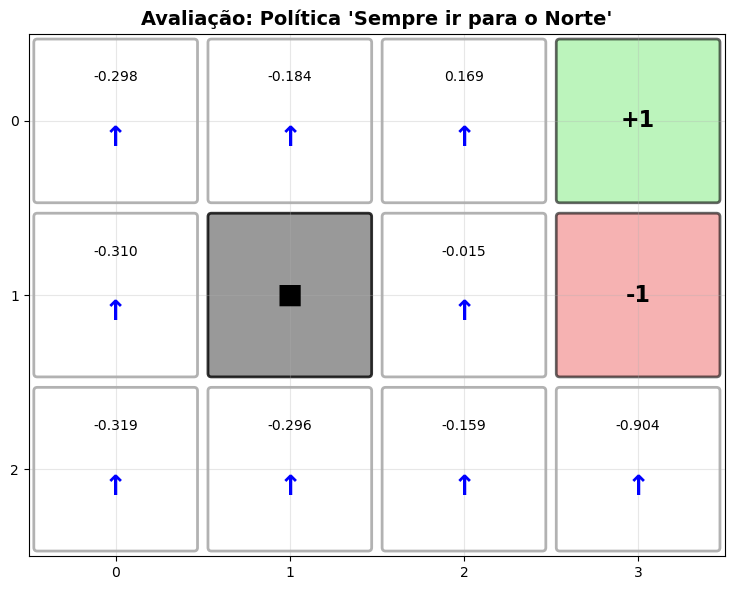

In [26]:
# Definindo uma política determinística fixa: 0 (Norte) para todos os estados
politica_sempre_norte = np.zeros(gw.nb_states, dtype=int)

# Executando a Avaliação Iterativa de Política
V_norte = iter_policy_eval(gw, politica_sempre_norte, gamma=0.9, theta=1e-5)

# Visualizando a Função de Valor (V) para esta política
visualize_gridworld(
    gw, 
    values=V_norte, 
    policy=politica_sempre_norte, 
    title="Avaliação: Política 'Sempre ir para o Norte'"
)
plt.show()

In [27]:
# Como é uma politica:
politica_sempre_norte

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

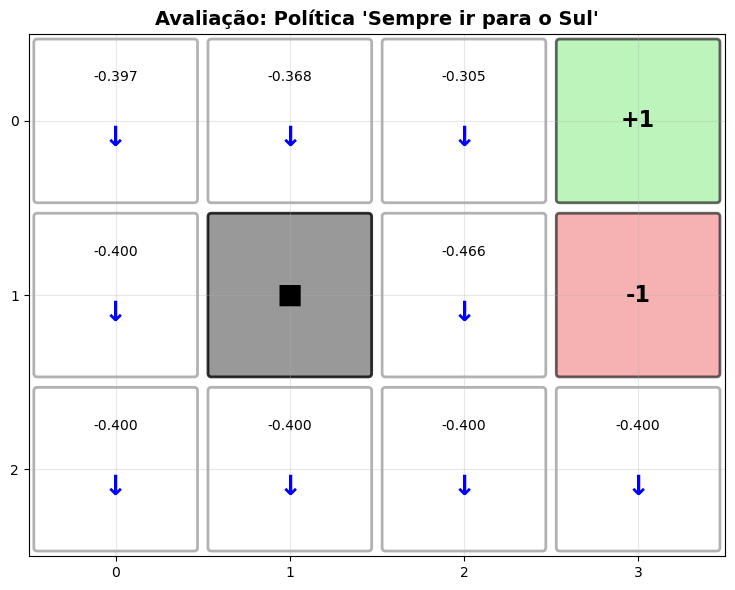

In [28]:
# Definindo uma política determinística fixa: 1 (Sul) para todos os estados
politica_sempre_sul = np.ones(gw.nb_states, dtype=int)

# Executando a Avaliação Iterativa de Política
V_sul = iter_policy_eval(gw, politica_sempre_sul, gamma=0.9, theta=1e-5)

# Visualizando a Função de Valor (V) para esta política
visualize_gridworld(
    gw, 
    values=V_sul, 
    policy=politica_sempre_sul, 
    title="Avaliação: Política 'Sempre ir para o Sul'"
)
plt.show()

In [29]:
# Como é a politica
politica_sempre_sul

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

Vamos avaliar uma outra política ingênua: o agente sempre tenta ir para o Leste (Ação 2), independentemente de onde esteja.

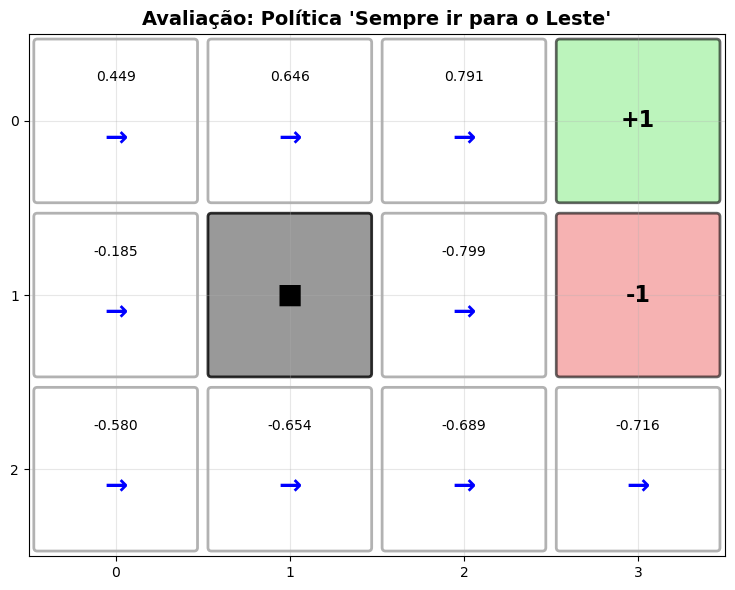

In [30]:
# Definindo uma política determinística fixa: 2 (Leste) para todos os estados
politica_sempre_leste = np.ones(gw.nb_states, dtype=int)*2

# Executando a Avaliação Iterativa de Política
V_leste = iter_policy_eval(gw, politica_sempre_leste, gamma=0.9, theta=1e-5)

# Visualizando a Função de Valor (V) para esta política
visualize_gridworld(
    gw, 
    values=V_leste, 
    policy=politica_sempre_leste, 
    title="Avaliação: Política 'Sempre ir para o Leste'"
)
plt.show()

In [31]:
# Vamos vere sta politica
politica_sempre_leste

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

Vamos avaliar uma outra política ingênua: o agente sempre tenta ir para o Oeste (Ação 4), independentemente de onde esteja.

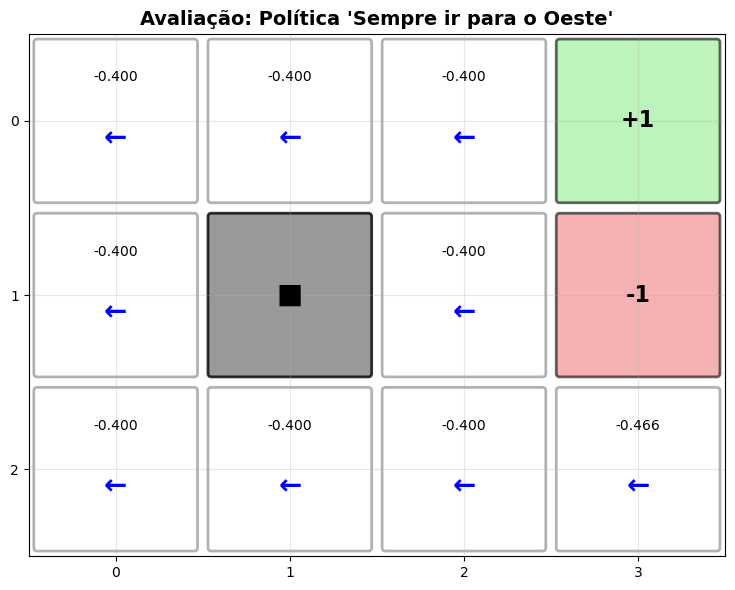

In [32]:
# Definindo uma política determinística fixa: 3 (Oeste) para todos os estados
politica_sempre_oeste = np.ones(gw.nb_states, dtype=int)*3

# Executando a Avaliação Iterativa de Política
V_oeste = iter_policy_eval(gw, politica_sempre_oeste, gamma=0.9, theta=1e-5)

# Visualizando a Função de Valor (V) para esta política
visualize_gridworld(
    gw, 
    values=V_oeste, 
    policy=politica_sempre_oeste, 
    title="Avaliação: Política 'Sempre ir para o Oeste'"
)
plt.show()

In [33]:
# Qual politica de maior valor médio

print('V_norte')
print(V_norte)
print(np.mean(V_norte))

print('V_sul')
print(V_sul)
print(np.mean(V_sul))

print('V_leste')
print(V_leste)
print(np.mean(V_leste))

print('V_oeste')
print(V_oeste)
print(np.mean(V_oeste))

V_norte
[-0.2976695  -0.18406207  0.16941764  0.         -0.31014693  0.
 -0.01540555  0.         -0.31866078 -0.2964076  -0.15909688 -0.90364692]
-0.1929732153307504
V_sul
[-0.39678984 -0.36827106 -0.30456751  0.         -0.39992055  0.
 -0.46587282  0.         -0.39992136 -0.3999278  -0.39993173 -0.39993355]
-0.2945946848770173
V_leste
[ 0.44891715  0.64604258  0.79132615  0.         -0.18485694  0.
 -0.79881429  0.         -0.57967023 -0.65398505 -0.68926959 -0.7157605 ]
-0.14467256084153177
V_oeste
[-0.3999184  -0.39992642 -0.39993426  0.         -0.39992434  0.
 -0.39993905  0.         -0.39992709 -0.39993426 -0.39994126 -0.46588704]
-0.3054443438618858


## 3. Iteração de Valor (Value Iteration)

Agora queremos responder: *"Qual a melhor estratégia possível?"*. 

Para encontrar a Política Ótima ($\pi^*$), utilizamos a **Equação de Otimalidade de Bellman**. Em vez de avaliar uma ação fixa, o agente busca ativamente a ação que maximiza o retorno futuro. A utilidade ótima é propagada por todo o espaço de estados até convergir.

A atualização iterativa é dada por:

$$V^*(s) = \max_{a \in A} \sum_{s', r} p(s', r | s, a) \left[ r + \gamma V^*(s') \right]$$

Uma vez que os valores ótimos $V^*$ convergem, a política ótima $\pi^*$ é extraída escolhendo a ação que maximiza essa soma para cada estado.

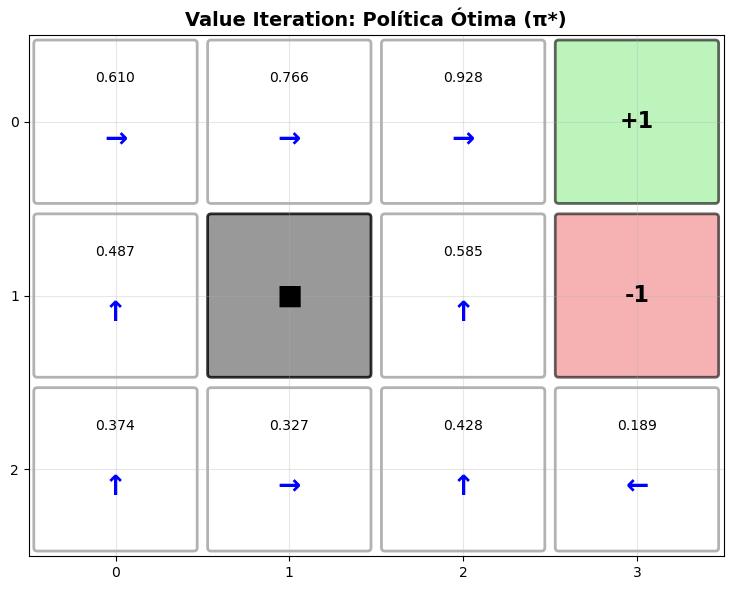

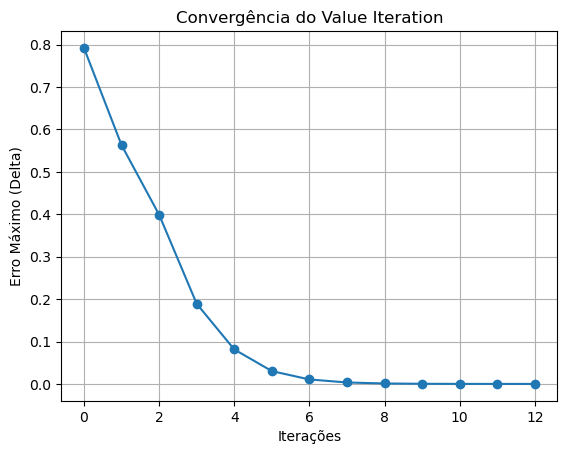

In [34]:
# Executando o algoritmo Value Iteration
V_otimo, politica_otima, historico_deltas = value_iteration(gw, gamma=0.9, theta=1e-5)

# Visualizando a Política Ótima encontrada
visualize_gridworld(
    gw, 
    values=V_otimo, 
    policy=politica_otima, 
    title="Value Iteration: Política Ótima (π*)"
)
plt.show()

# Plotando a curva de convergência matemática
plt.plot(historico_deltas, marker='o', linestyle='-')
plt.title("Convergência do Value Iteration")
plt.xlabel("Iterações")
plt.ylabel("Erro Máximo (Delta)")
plt.grid(True)
plt.show()

## 4. Iteração de Política (Policy Iteration)

O **Policy Iteration** é um algoritmo fundamental alternativo. Em vez de usar o operador de maximização diretamente no valor, ele divide o problema em duas etapas que se repetem até a estabilidade:

1. **Avaliação da Política:** Calcula $V^\pi(s)$ para a política atual $\pi$ até convergir.
2. **Melhoria da Política:** Atualiza a política atuando de forma gulosa em relação aos novos valores calculados:

$$\pi'(s) = \arg\max_{a \in A} \sum_{s', r} p(s', r | s, a) \left[ r + \gamma V^\pi(s') \right]$$

Este método costuma exigir menos iterações externas para convergir do que a Iteração de Valor.

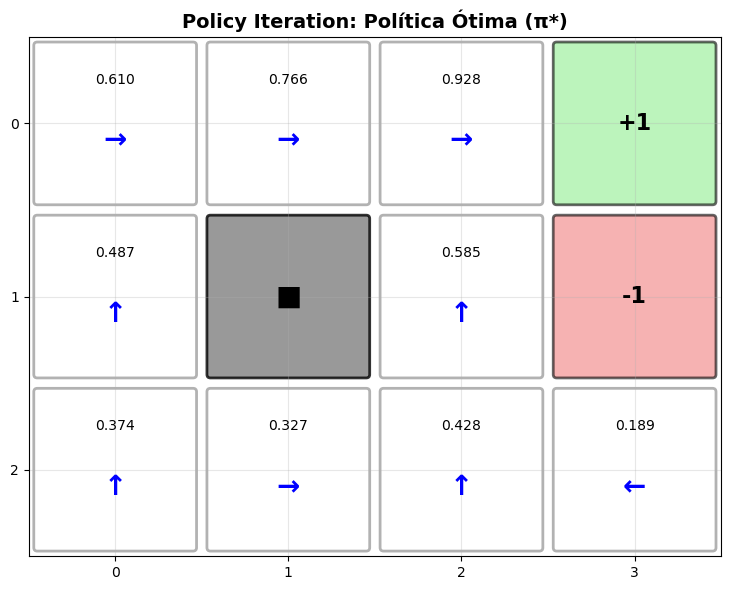

O algoritmo Policy Iteration convergiu em 4 passos de melhoria da política.
Mudanças na política por iteração: [8, 5, 2, 0]


In [35]:
# Executando o algoritmo Policy Iteration
V_pi_otimo, poli_pi_otima, evals_history, changes_history = policy_iteration(gw, gamma=0.9, theta=1e-5)

# Visualizando a Política Ótima (deve ser idêntica ao Value Iteration)
visualize_gridworld(
    gw, 
    values=V_pi_otimo, 
    policy=poli_pi_otima, 
    title="Policy Iteration: Política Ótima (π*)"
)
plt.show()

# Analisando o comportamento da convergência
print(f"O algoritmo Policy Iteration convergiu em {len(changes_history)} passos de melhoria da política.")
print(f"Mudanças na política por iteração: {changes_history}")

## 5. O Desafio do Cliff World (Mundo do Precipício)

Agora vamos aplicar a Programação Dinâmica em um ambiente muito mais perigoso: o **Cliff World**.

Imagine que o agente começa no canto inferior esquerdo e o objetivo está no canto inferior direito. O caminho mais curto é ir em linha reta pela borda inferior. No entanto, o trecho entre o início e o objetivo é um enorme precipício.

**Regras do Ambiente:**
* **Dimensões:** Grid de 4 linhas por 8 colunas.
* **Recompensa de Vida:** $R = -1.0$ por passo (incentiva a pressa).
* **Precipício (Cliff):** Cair no precipício gera uma punição severa de $R = -100.0$ e encerra o episódio.
* **Objetivo (Goal):** Chegar ao final rende $R = 0.0$ (o que é ótimo, pois para de acumular o custo de vida).

Para tornar as equações de Bellman mais interessantes, vamos injetar **10% de ruído** ($noise = 0.1$). Isso significa que, se o agente tentar andar na beiradinha do precipício, há uma chance de ele escorregar e cair.

INFORMAÇÕES DO GRIDWORLD
Dimensões: 4 linhas x 8 colunas
Total de estados: 32
Paredes: 0
Estados terminais: 7
Fator de desconto (γ): 0.9
Ruído: 0.1
Living reward: -1.0
Ações disponíveis: ['N', 'S', 'L', 'O']

Estados terminais:
  (3, 1): reward = -100.0
  (3, 2): reward = -100.0
  (3, 3): reward = -100.0
  (3, 4): reward = -100.0
  (3, 5): reward = -100.0
  (3, 6): reward = -100.0
  (3, 7): reward = 0.0


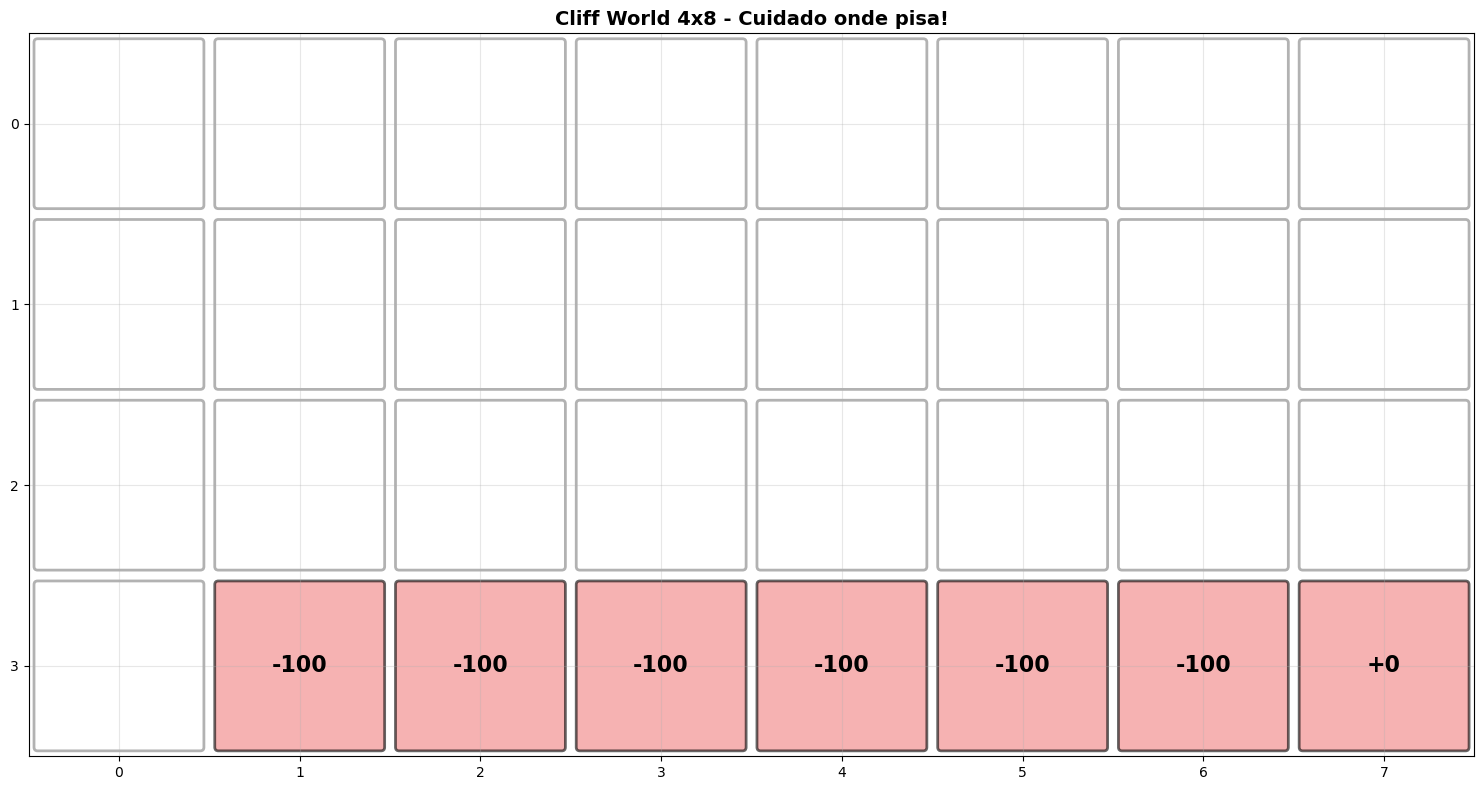

In [36]:
# Importando o novo ambiente do nosso módulo
from environment import create_cliff_world_2

# Criando o ambiente Cliff World com 10% de ruído (escorregadio)
# Usamos a versão 2, onde o objetivo está na última linha, última coluna
gw_cliff = create_cliff_world_2(rows=4, cols=8, noise=0.1)

# Imprimindo as informações para confirmar as penalidades
print_gridworld_info(gw_cliff)

# Visualizando a geografia (Atente-se à linha de baixo: Início -> Precipício -> Objetivo)
visualize_gridworld(gw_cliff, title="Cliff World 4x8 - Cuidado onde pisa!")
plt.show()

### 5.1 Avaliando uma Política Suicida no Cliff World

O que acontece se o agente for ganancioso e tentar o caminho mais curto?

Vamos usar a **Avaliação de Política** (Policy Evaluation) para calcular a Função de Valor $V^\pi(s)$ de uma política onde a regra é: *"Sempre ande para o Leste (Direita)"*. 

Como o agente começa na mesma linha do precipício, andar para o leste o jogará direto no buraco. Veremos a matemática punindo severamente os estados iniciais.

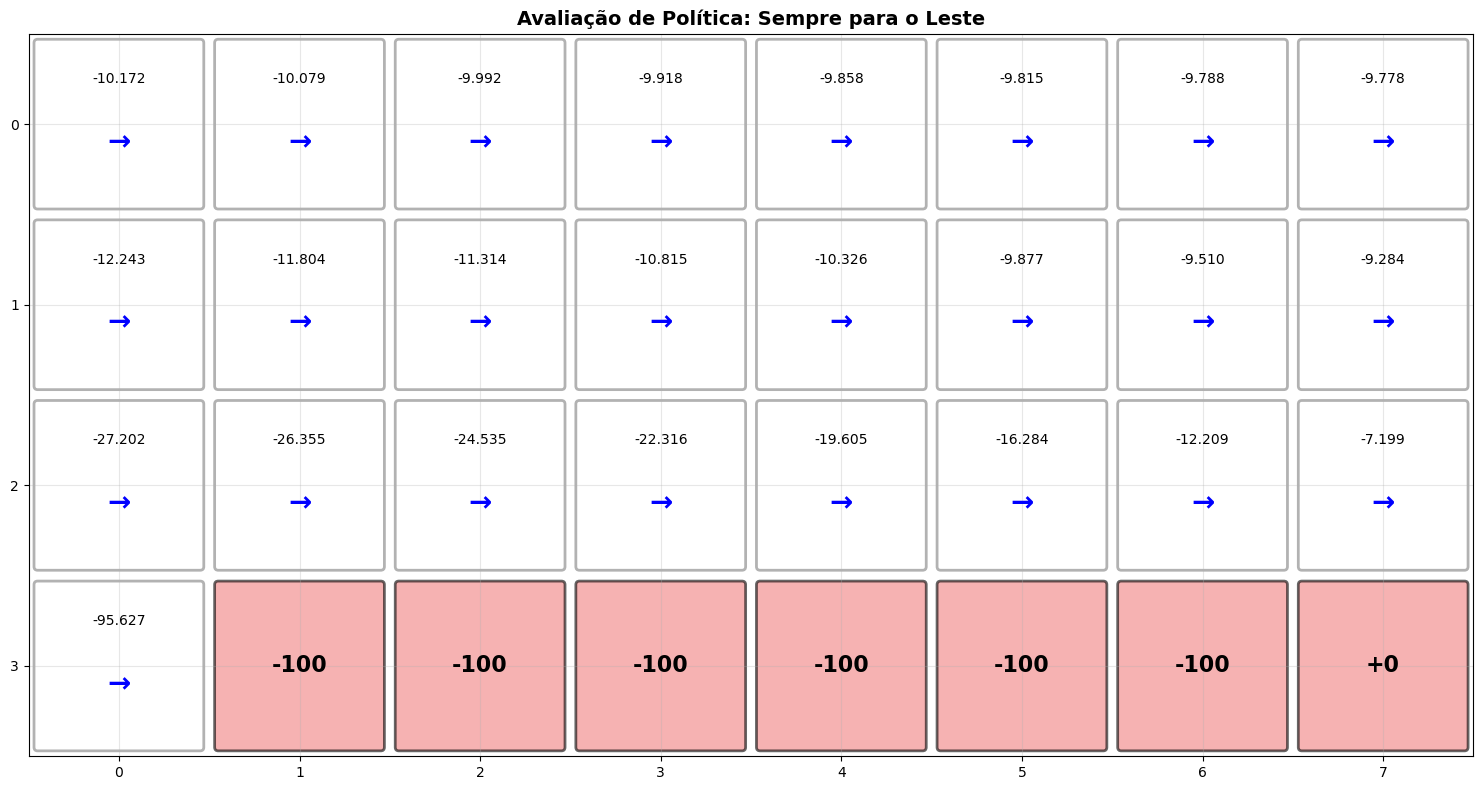

In [37]:
# Ações: 0='N', 1='S', 2='L', 3='O'. Vamos forçar a ação 2 (Leste)
politica_suicida_l = np.full(gw_cliff.nb_states, 2, dtype=int)

# Avaliando essa péssima ideia
V_suicida_l = iter_policy_eval(gw_cliff, politica_suicida_l, gamma=0.9, theta=1e-5)

# Visualizando o desastre: Note como os valores V(s) ficam extremamente negativos
visualize_gridworld(
    gw_cliff, 
    values=V_suicida_l, 
    policy=politica_suicida_l, 
    title="Avaliação de Política: Sempre para o Leste"
)
plt.show()

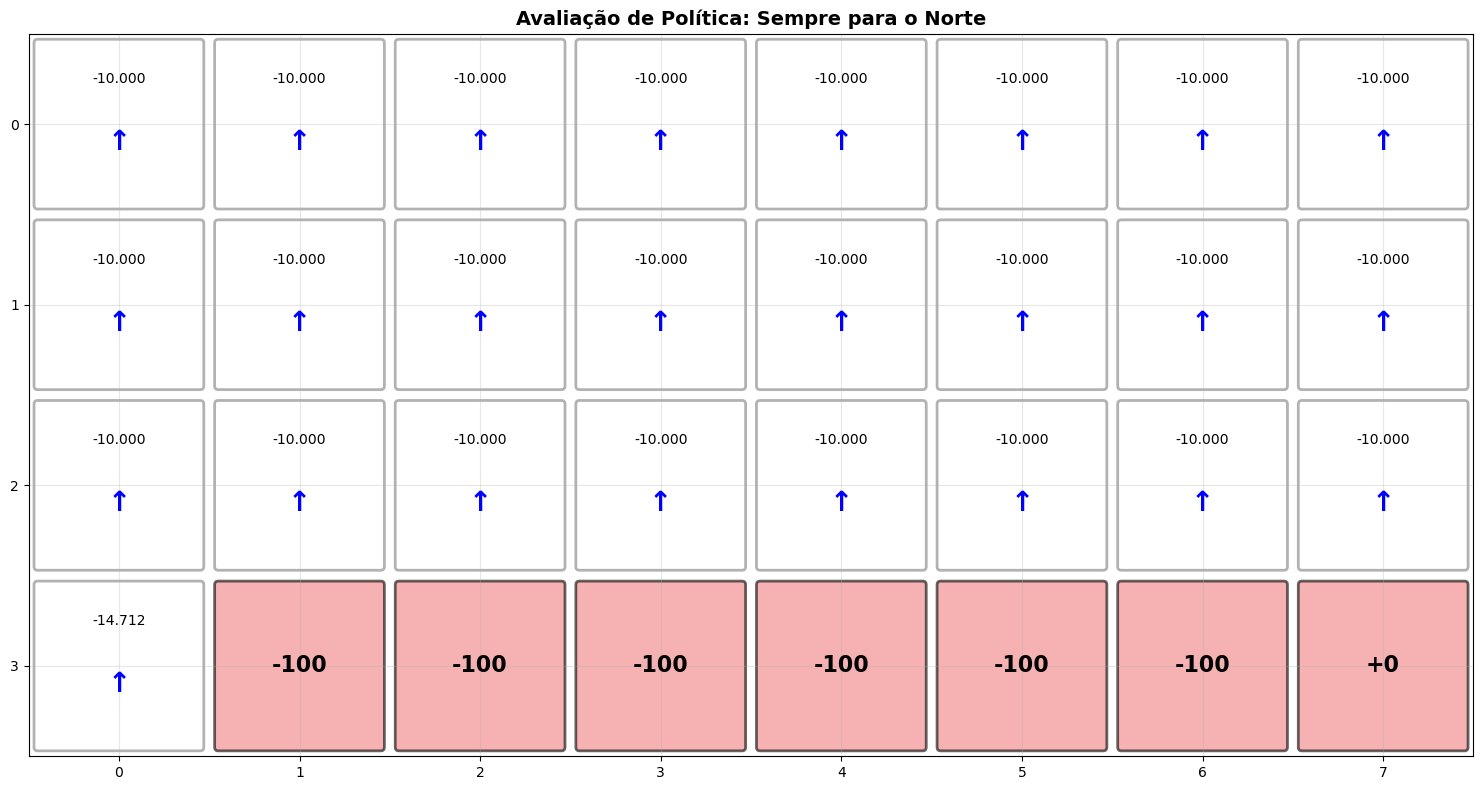

In [38]:
# Ações: 0='N', 1='S', 2='L', 3='O'. Vamos forçar a ação 0 (Norte)
politica_suicida_n = np.full(gw_cliff.nb_states, 0, dtype=int)

# Avaliando essa péssima ideia
V_suicida_n = iter_policy_eval(gw_cliff, politica_suicida_n, gamma=0.9, theta=1e-5)

# Visualizando o desastre: Note como os valores V(s) ficam extremamente negativos
visualize_gridworld(
    gw_cliff, 
    values=V_suicida_n, 
    policy=politica_suicida_n, 
    title="Avaliação de Política: Sempre para o Norte"
)
plt.show()

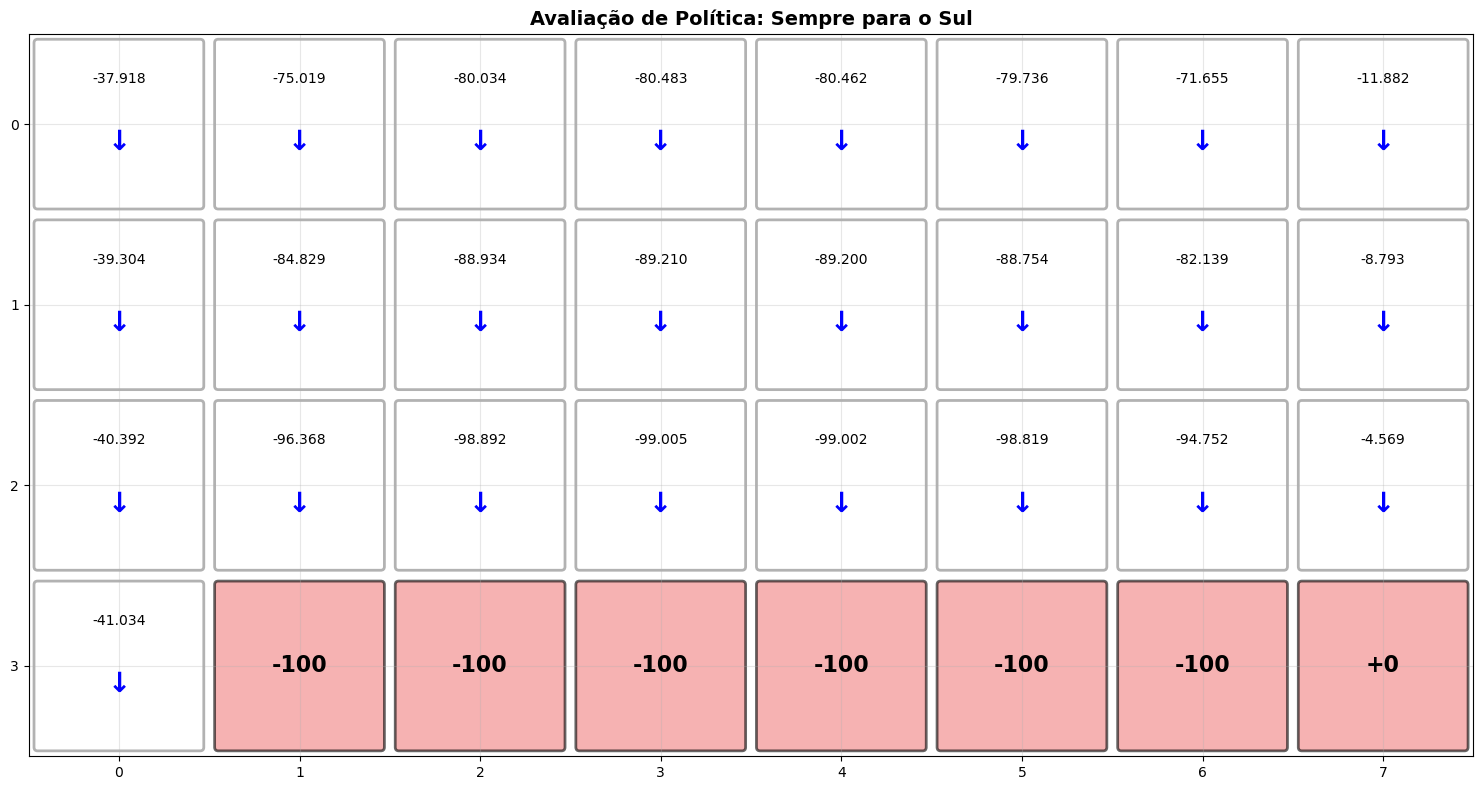

In [39]:
# Ações: 0='N', 1='S', 2='L', 3='O'. Vamos forçar a ação 1 (Sul)
politica_suicida_s = np.full(gw_cliff.nb_states, 1, dtype=int)

# Avaliando essa péssima ideia
V_suicida_s = iter_policy_eval(gw_cliff, politica_suicida_s, gamma=0.9, theta=1e-5)

# Visualizando o desastre: Note como os valores V(s) ficam extremamente negativos
visualize_gridworld(
    gw_cliff, 
    values=V_suicida_s, 
    policy=politica_suicida_s, 
    title="Avaliação de Política: Sempre para o Sul"
)
plt.show()

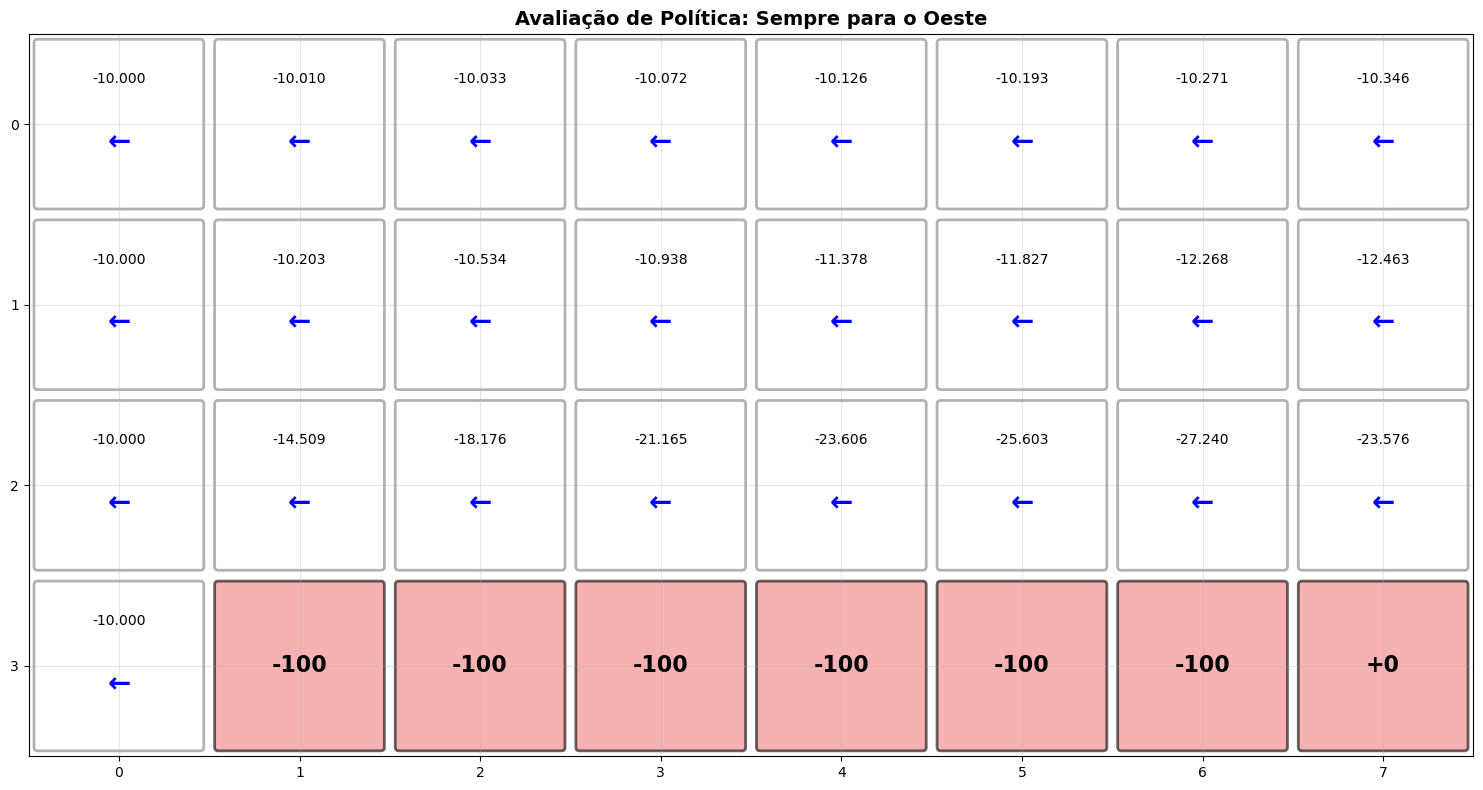

In [40]:
# Ações: 0='N', 1='S', 2='L', 3='O'. Vamos forçar a ação 3 (Oeste)
politica_suicida_o = np.full(gw_cliff.nb_states, 3, dtype=int)

# Avaliando essa péssima ideia
V_suicida_o = iter_policy_eval(gw_cliff, politica_suicida_o, gamma=0.9, theta=1e-5)

# Visualizando o desastre: Note como os valores V(s) ficam extremamente negativos
visualize_gridworld(
    gw_cliff, 
    values=V_suicida_o, 
    policy=politica_suicida_o, 
    title="Avaliação de Política: Sempre para o Oeste"
)
plt.show()

In [41]:
V_suicida_o

array([ -9.99991824, -10.00950831, -10.03323031, -10.07239721,
       -10.12633465, -10.19324031, -10.27076181, -10.34572823,
        -9.99992455, -10.20327546, -10.53408605, -10.93829704,
       -11.37796389, -11.82697535, -12.26785101, -12.46341703,
        -9.99992833, -14.50908934, -18.17639624, -21.16510432,
       -23.60574288, -25.60286562, -27.24037445, -23.57555707,
        -9.99993006,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ])

### 5.2 Value Iteration: Encontrando o Caminho Seguro

Sabendo que o chão é escorregadio (devido ao ruído de 10%), a Equação de Otimalidade de Bellman vai perceber que andar colado no precipício tem um Valor Esperado muito negativo, pois a chance matemática de escorregar e tomar a penalidade de $-100$ destrói o retorno do caminho mais curto.

Vamos rodar a **Iteração de Valor** (Value Iteration) para extrair a Política Ótima. Observe como o agente matematicamente decide "dar a volta" por cima, preferindo tomar penalidades de $-1$ extras por fazer um caminho mais longo do que arriscar a queda de $-100$.

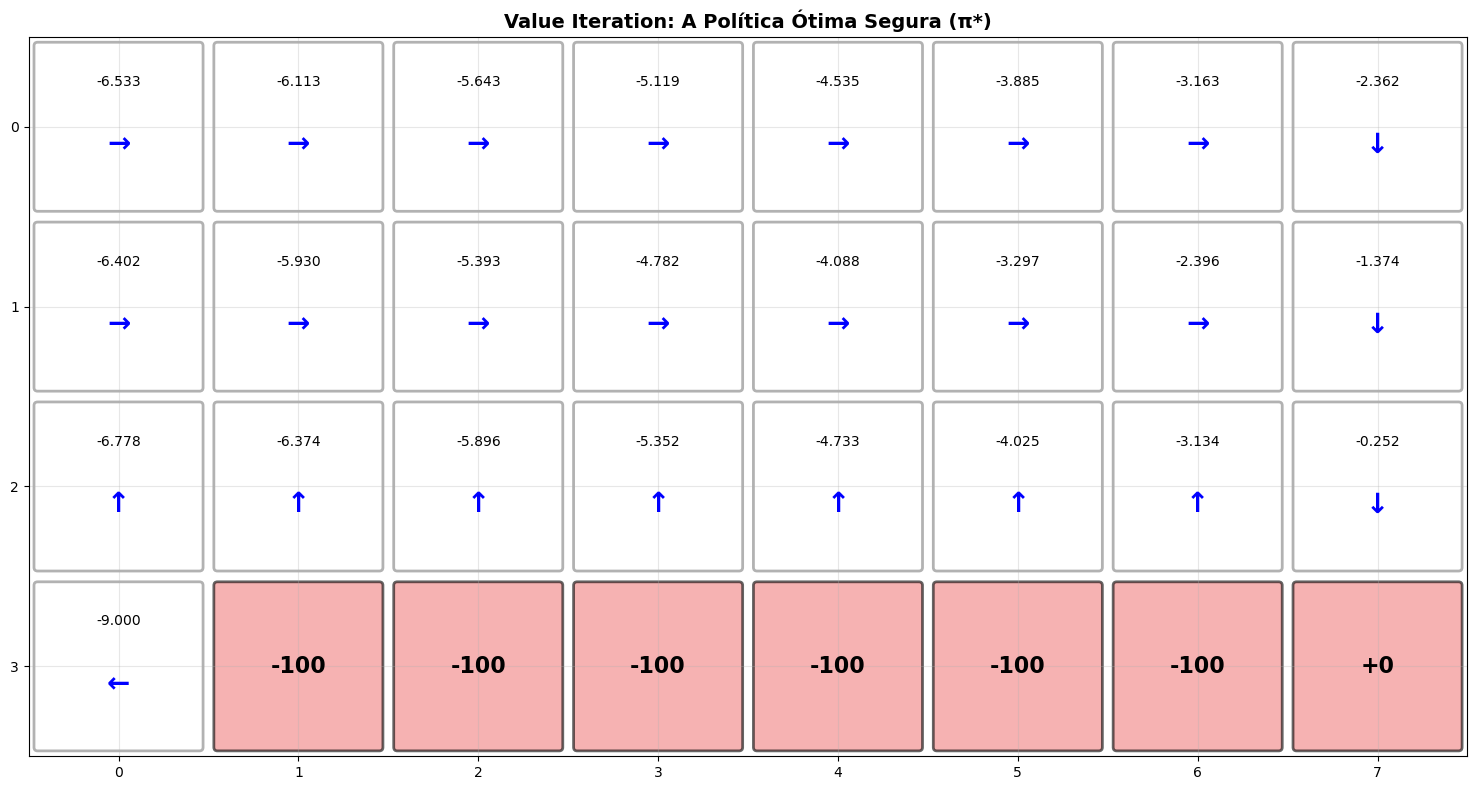

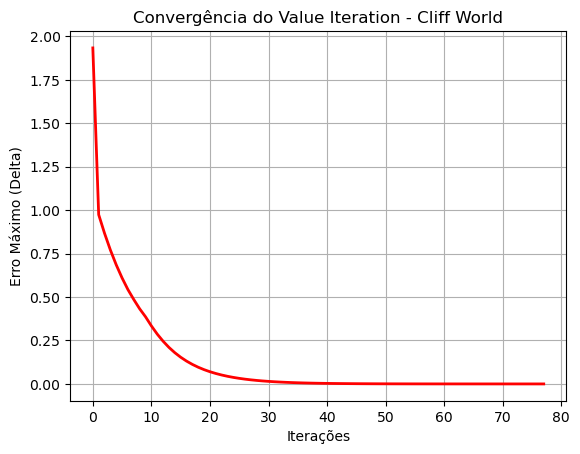

In [37]:
# Executando o algoritmo Value Iteration no Cliff World
V_cliff_otimo, poli_cliff_otima, deltas_cliff = value_iteration(gw_cliff, gamma=0.9, theta=1e-5)

# Visualizando a rota segura escolhida pela matemática
visualize_gridworld(
    gw_cliff, 
    values=V_cliff_otimo, 
    policy=poli_cliff_otima, 
    title="Value Iteration: A Política Ótima Segura (π*)"
)
plt.show()

# Gráfico de convergência
plt.plot(deltas_cliff, color='red', linewidth=2)
plt.title("Convergência do Value Iteration - Cliff World")
plt.xlabel("Iterações")
plt.ylabel("Erro Máximo (Delta)")
plt.grid(True)
plt.show()

In [38]:
V_cliff_otimo

array([-6.53344391, -6.11275715, -5.64300068, -5.11899959, -4.53512003,
       -3.88530434, -3.16308769, -2.36162066, -6.40234759, -5.93005621,
       -5.39279962, -4.78216408, -4.08762474, -3.29699162, -2.39635565,
       -1.37408492, -6.77771308, -6.3736543 , -5.89581519, -5.35184572,
       -4.73291395, -4.02455226, -3.13350932, -0.25236431, -8.99992509,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ])

In [39]:
poli_cliff_otima

array([2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 3, 0, 0, 0, 0, 0, 0, 0])

In [40]:
poli_cliff_otima[24]

3

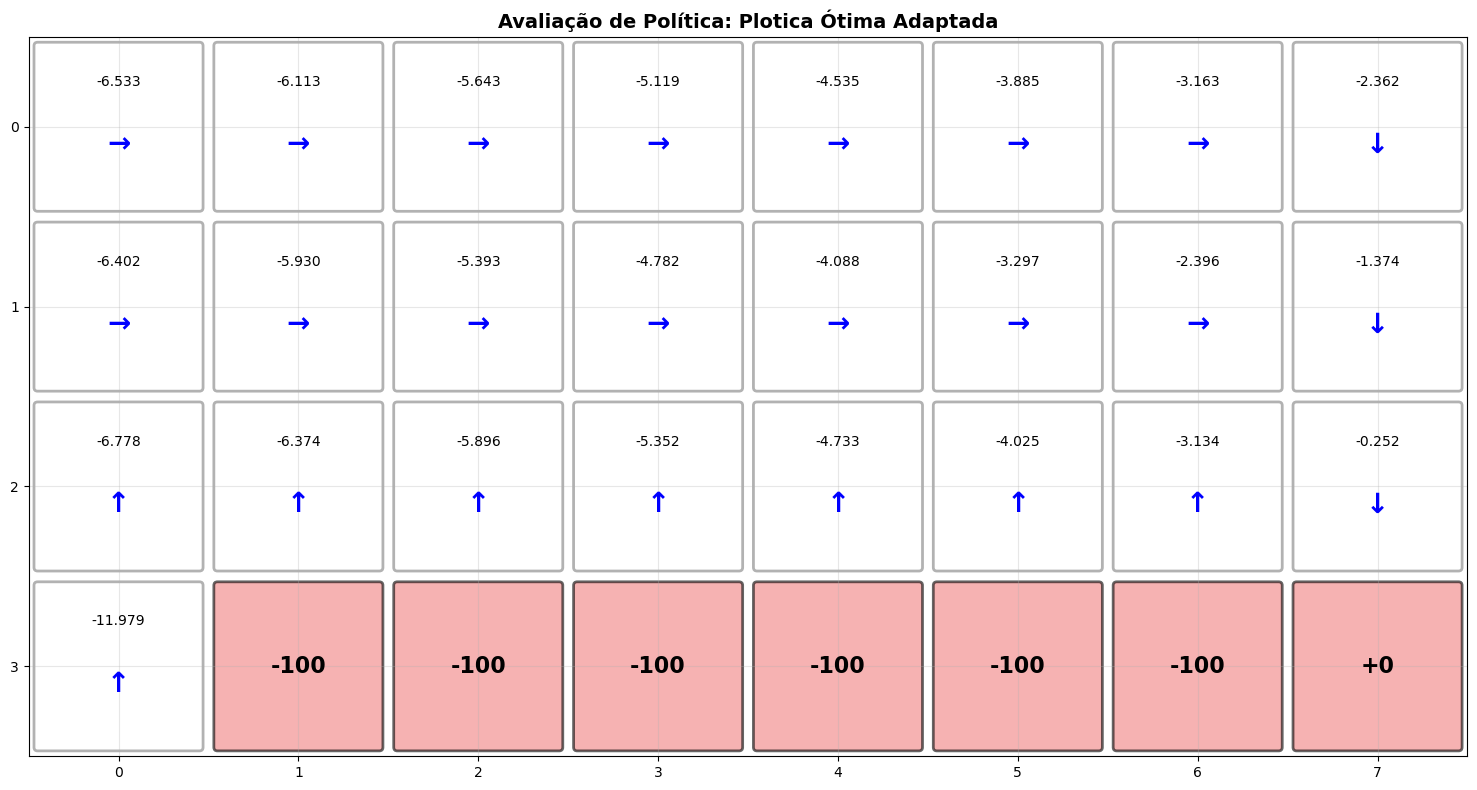

In [41]:
# Ações: 0='N', 1='S', 2='L', 3='O'. Vamos forçar a ação 0 (Norte)
politica_adaptada = poli_cliff_otima
politica_adaptada[24]=0

# Avaliando essa péssima ideia
V_adaptada = iter_policy_eval(gw_cliff, politica_adaptada, gamma=0.9, theta=1e-5)

# Visualizando o desastre: Note como os valores V(s) ficam extremamente negativos
visualize_gridworld(
    gw_cliff, 
    values=V_adaptada, 
    policy=politica_adaptada, 
    title="Avaliação de Política: Plotica Ótima Adaptada"
)
plt.show()

### 5.3 Policy Iteration no Cliff World

Para encerrar nossa análise de Programação Dinâmica, vamos confirmar que o algoritmo de **Iteração de Política** (Policy Iteration) chega exatamente à mesma conclusão de rota segura. 

Este algoritmo começará com uma política totalmente aleatória, vai avaliá-la, vai descobrir que ela cai no precipício, e fará melhorias gulosas sucessivas até estabilizar na rota pelo topo do grid.

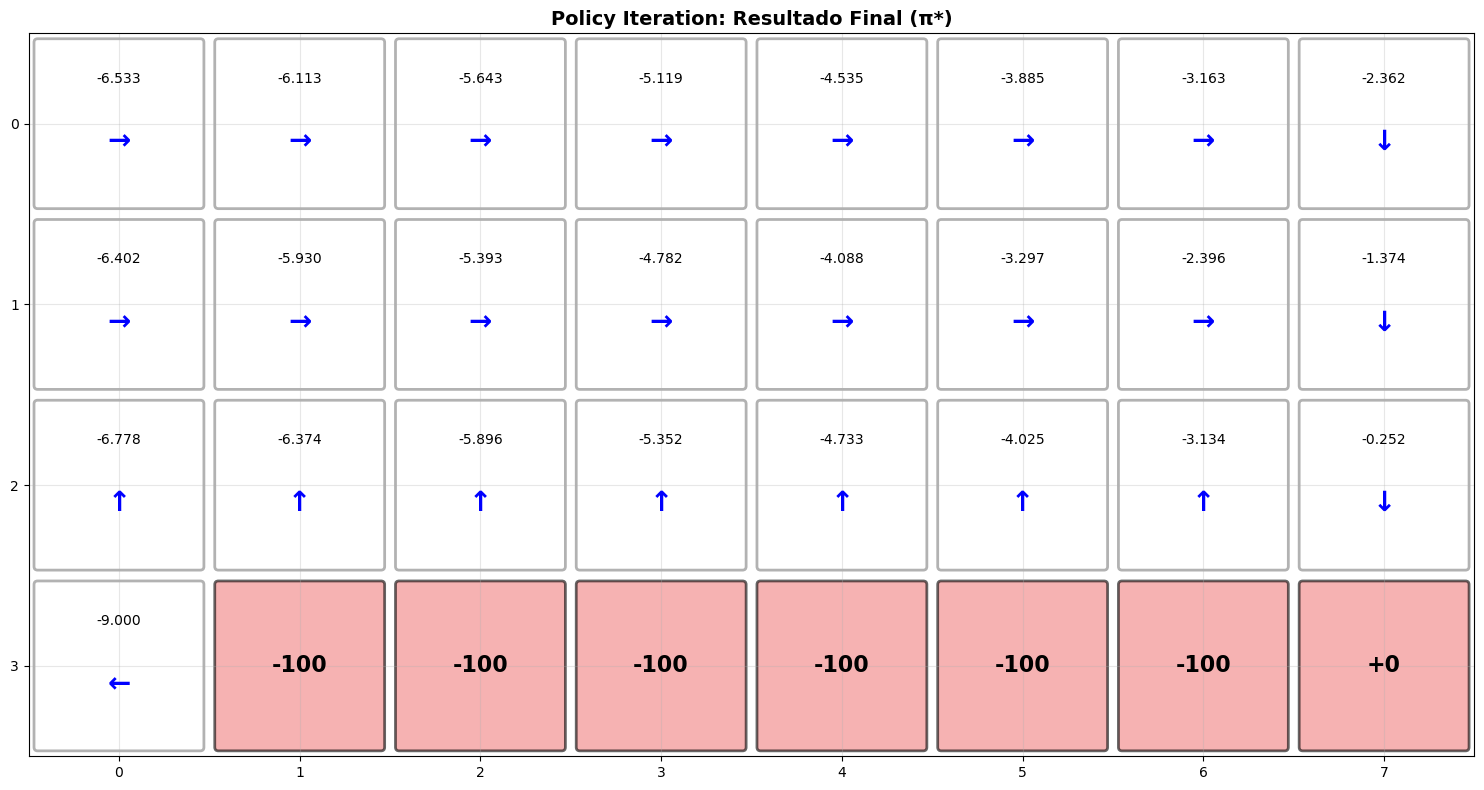

Policy Iteration precisou de 5 passos de melhoria para encontrar a rota segura.


In [46]:
# Executando Policy Iteration
V_pi_cliff, poli_pi_cliff, evals_c, changes_c = policy_iteration(gw_cliff, gamma=0.9, theta=1e-5)

# A política gerada deve ser idêntica à do Value Iteration
visualize_gridworld(
    gw_cliff, 
    values=V_pi_cliff, 
    policy=poli_pi_cliff, 
    title="Policy Iteration: Resultado Final (π*)"
)
plt.show()

print(f"Policy Iteration precisou de {len(changes_c)} passos de melhoria para encontrar a rota segura.")

## 6. Experimento Heurístico: A Política do "Melhor Movimento Contínuo"

Neste experimento, vamos testar uma intuição curiosa: o que acontece se avaliarmos 4 políticas ingênuas (sempre Norte, sempre Sul, sempre Leste, sempre Oeste) e tentarmos "costurar" uma nova política usando as melhores partes de cada uma?

**O procedimento será:**
1. Avaliar as 4 políticas constantes para obter $V_N, V_S, V_L, V_O$.
2. Para cada estado $s$, definir a ação da nova política $\pi_{heur}$ escolhendo a direção cujo $V(s)$ foi o maior:
   $$\pi_{heur}(s) = \arg\max_{a \in \{N,S,L,O\}} V_a(s)$$
3. Avaliar essa nova política heurística para encontrar seu valor real $V^{\pi_{heur}}$.
4. Comparar com o $V^*$ gerado pelo Value Iteration.

**A Hipótese:** Será que essa composição de "qual direção fixa dói menos" consegue igualar a Política Ótima verdadeira?

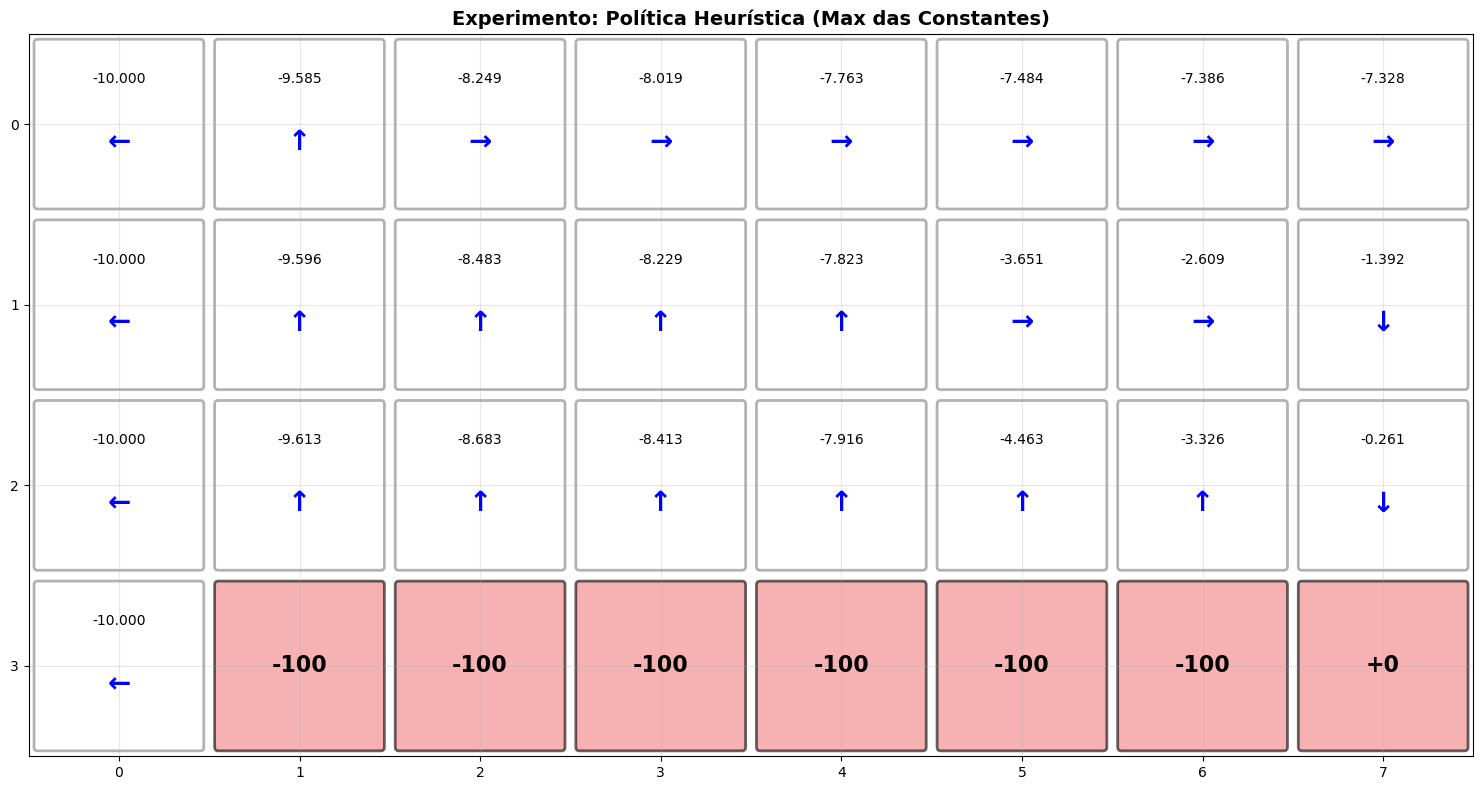

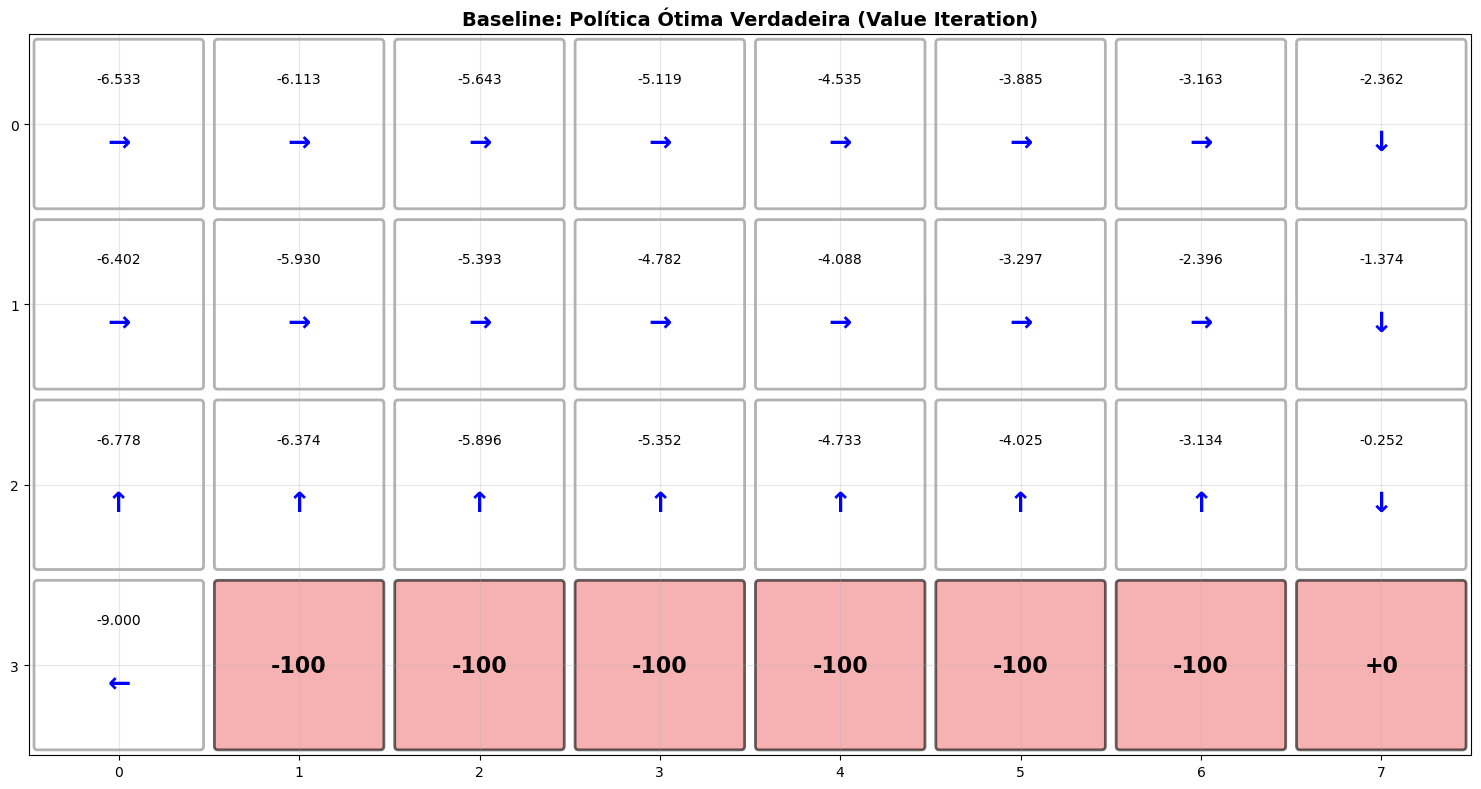

COMPARAÇÃO DE RESULTADOS
Valor Médio da Política Heurística : -5.63
Valor Médio da Política Ótima      : -3.64

A Política Ótima é melhor em média por 1.99 pontos por estado.
A heurística conseguiu superar a ótima em algum estado? Não, matematicamente impossível.


In [42]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Recriando o ambiente para garantir que está limpo (ruído 10%)
gw_cliff = create_cliff_world_2(rows=4, cols=8, noise=0.1)

# 2. Criando as 4 políticas constantes (Ações: 0='N', 1='S', 2='L', 3='O')
politica_n = np.full(gw_cliff.nb_states, 0, dtype=int)
politica_s = np.full(gw_cliff.nb_states, 1, dtype=int)
politica_l = np.full(gw_cliff.nb_states, 2, dtype=int)
politica_o = np.full(gw_cliff.nb_states, 3, dtype=int)

# 3. Avaliando todas as 4 políticas
V_n = iter_policy_eval(gw_cliff, politica_n, gamma=0.9, theta=1e-5)
V_s = iter_policy_eval(gw_cliff, politica_s, gamma=0.9, theta=1e-5)
V_l = iter_policy_eval(gw_cliff, politica_l, gamma=0.9, theta=1e-5)
V_o = iter_policy_eval(gw_cliff, politica_o, gamma=0.9, theta=1e-5)

# 4. Construindo a Política Heurística
# Empilhamos os vetores de valor na ordem dos índices das ações [0, 1, 2, 3]
V_empilhados = np.vstack([V_n, V_s, V_l, V_o]) # Formato: (4 matrizes x nb_states)

# argmax ao longo do eixo 0 (as 4 ações) nos dá o índice da ação com maior valor!
politica_heuristica = np.argmax(V_empilhados, axis=0)

# 5. Avaliando a nova Política Heurística
V_heuristica = iter_policy_eval(gw_cliff, politica_heuristica, gamma=0.9, theta=1e-5)

# 6. Gerando o Ótimo Verdadeiro para base de comparação
V_otimo, poli_otima, _ = value_iteration(gw_cliff, gamma=0.9, theta=1e-5)

# ==========================================
# VISUALIZAÇÕES
# ==========================================

# Gráfico 1: A Política Heurística Gerada
visualize_gridworld(
    gw_cliff, 
    values=V_heuristica, 
    policy=politica_heuristica, 
    title="Experimento: Política Heurística (Max das Constantes)"
)
plt.show()

# Gráfico 2: A Política Ótima Verdadeira
visualize_gridworld(
    gw_cliff, 
    values=V_otimo, 
    policy=poli_otima, 
    title="Baseline: Política Ótima Verdadeira (Value Iteration)"
)
plt.show()

# ==========================================
# COMPARAÇÃO ESTATÍSTICA
# ==========================================
print("="*60)
print("COMPARAÇÃO DE RESULTADOS")
print("="*60)
media_heuristica = np.mean([V_heuristica[s] for s in range(gw_cliff.nb_states)])
media_otima = np.mean([V_otimo[s] for s in range(gw_cliff.nb_states)])

print(f"Valor Médio da Política Heurística : {media_heuristica:.2f}")
print(f"Valor Médio da Política Ótima      : {media_otima:.2f}")

diferenca = media_otima - media_heuristica
print(f"\nA Política Ótima é melhor em média por {diferenca:.2f} pontos por estado.")

# Verificando se em algum estado a heurística venceu
venceu = np.any(V_heuristica > V_otimo + 1e-5) # 1e-5 para evitar erro de ponto flutuante
print(f"A heurística conseguiu superar a ótima em algum estado? {'Sim' if venceu else 'Não, matematicamente impossível.'}")

## Verificando o efeito do ruído no Cliff World

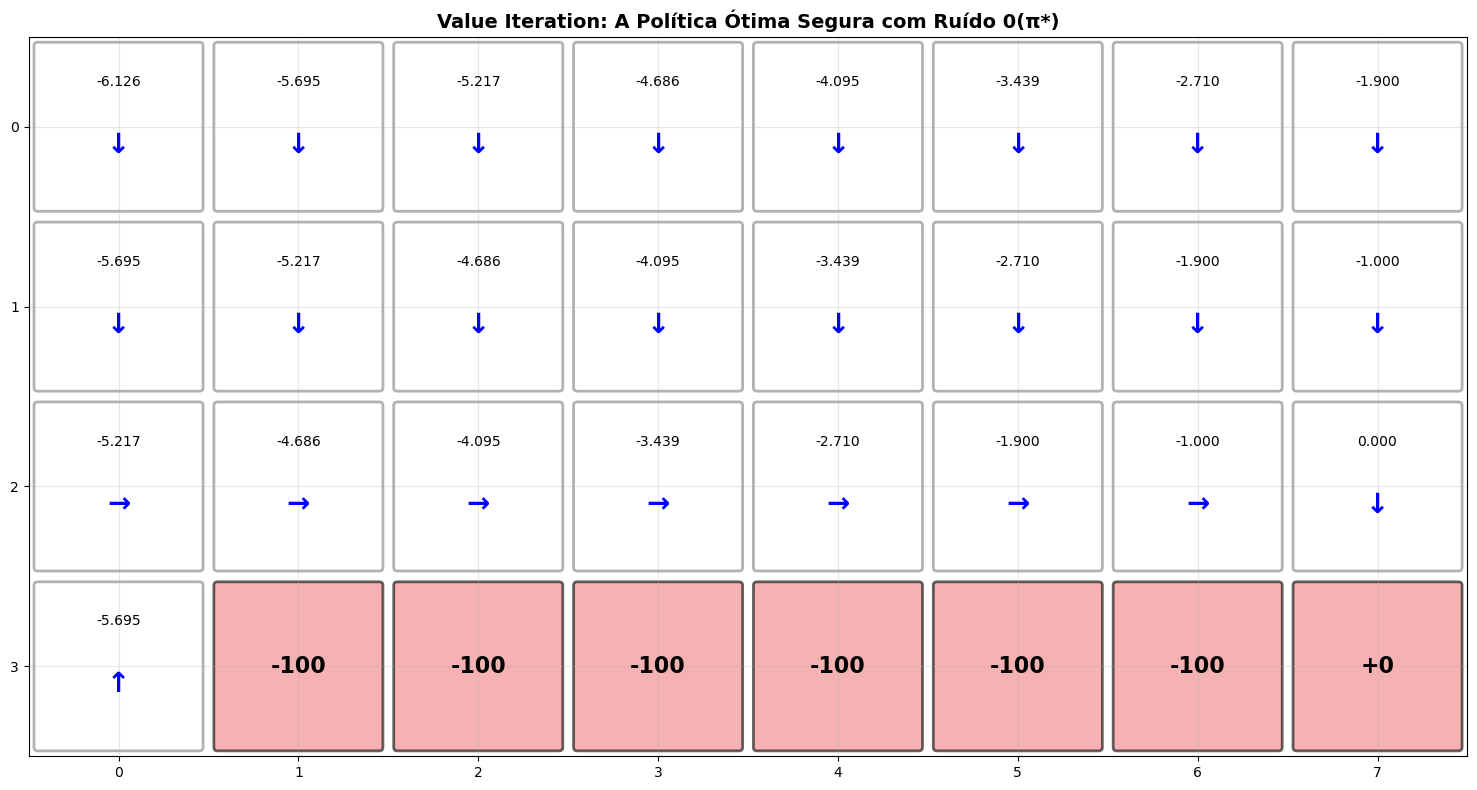

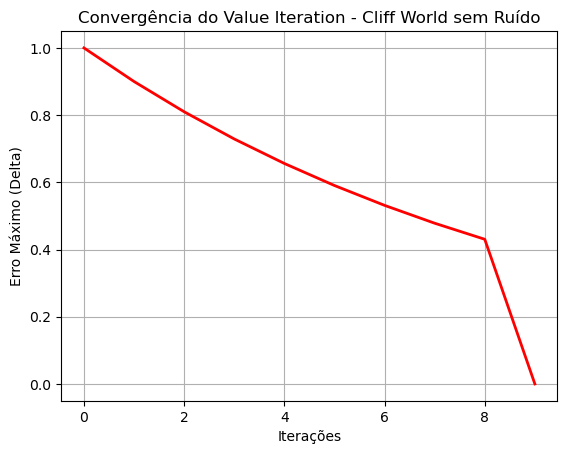

In [43]:
# 1. Recriando o ambiente para garantir que está limpo (ruído 10%)
gw_cliff_un = create_cliff_world_2(rows=4, cols=8, noise=0.0)

# Executando o algoritmo Value Iteration no Cliff World
V_cliff_otimo_un, poli_cliff_otima_un, deltas_cliff_un = value_iteration(gw_cliff_un, gamma=0.9, theta=1e-5)

# Visualizando a rota segura escolhida pela matemática
visualize_gridworld(
    gw_cliff_un, 
    values=V_cliff_otimo_un, 
    policy=poli_cliff_otima_un, 
    title="Value Iteration: A Política Ótima Segura com Ruído 0(π*)"
)
plt.show()

# Gráfico de convergência
plt.plot(deltas_cliff_un, color='red', linewidth=2)
plt.title("Convergência do Value Iteration - Cliff World sem Ruído")
plt.xlabel("Iterações")
plt.ylabel("Erro Máximo (Delta)")
plt.grid(True)
plt.show()

## 7. O Mundo Complexo (Custom GridWorld 10x10)

Até agora, resolvemos problemas em mapas pequenos. Mas o que acontece em um ambiente maior, repleto de paredes formando corredores, com múltiplos objetivos e várias armadilhas mortais?

Vamos usar a nossa função `create_custom_gridworld` para projetar um grid de 10x10. 

**Características do nosso Novo Mundo:**
* **Dimensões:** 10 linhas x 10 colunas.
* **Múltiplos Objetivos (Positivos):** * Recompensas Altas (+10) nos cantos direitos.
  * Recompensas Baixas (+2) nos cantos esquerdos (distrações).
* **Armadilhas (Negativos):** * Vários buracos de $-10$ bloqueando passagens e um poço de $-5$ no meio do mapa.
* **Paredes:** Obstáculos que forçam o agente a tomar decisões de roteamento.

Primeiro, vamos visualizar o mapa que acabamos de criar.

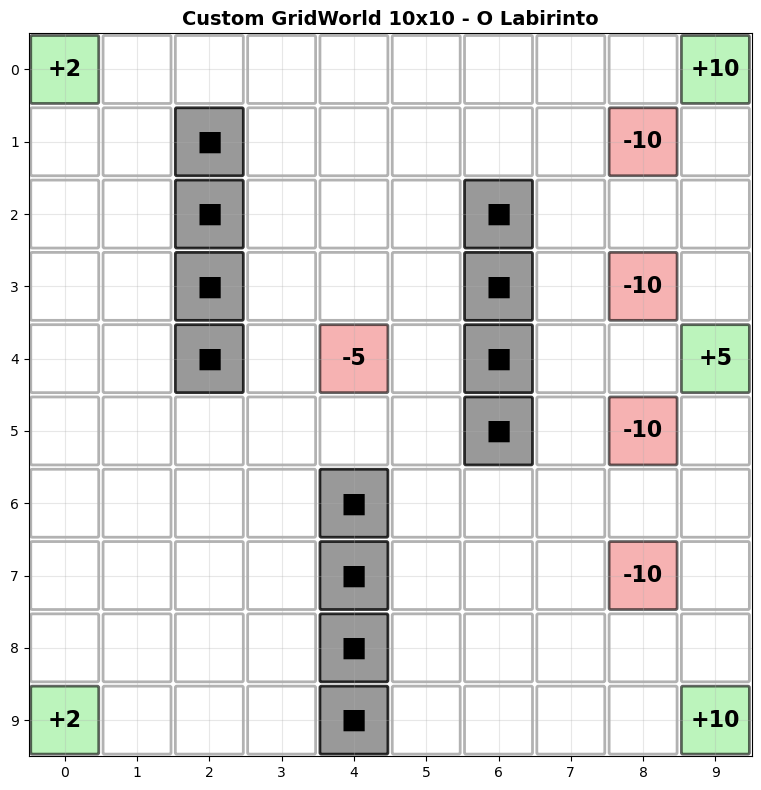

In [44]:
from environment import create_custom_gridworld

# Definindo a arquitetura do mapa 10x10
paredes = [
    (1,2), (2,2), (3,2), (4,2), # Muro esquerdo
    (6,4), (7,4), (8,4), (9,4), # Muro inferior
    (2,6), (3,6), (4,6), (5,6)  # Muro central
]

terminais = {
    # Recompensas Positivas (5)
    (0, 9): 10.0,  # Grande tesouro superior
    (4, 9): 5.0,   # Tesouro médio
    (9, 9): 10.0,  # Grande tesouro inferior
    (0, 0): 2.0,   # Distração (prêmio de consolação)
    (9, 0): 2.0,   # Distração (prêmio de consolação)
    
    # Armadilhas Negativas (5)
    (1, 8): -10.0, # Guarda o tesouro superior
    (3, 8): -10.0, # Campo minado
    (5, 8): -10.0, # Campo minado
    (7, 8): -10.0, # Guarda o tesouro inferior
    (4, 4): -5.0   # Buraco no meio do mapa
}

# Instanciando o ambiente com valores padrão temporários
gw_complex = create_custom_gridworld(
    rows=10, cols=10, 
    walls=paredes, 
    terminals=terminais,
    gamma=0.9, noise=0.1
)

visualize_gridworld(gw_complex, title="Custom GridWorld 10x10 - O Labirinto", figsize=(10, 8))
plt.show()

## 8. Experimento A: O Peso do Fator de Desconto ($\gamma$)

A Equação de Bellman utiliza o parâmetro $\gamma$ (Gama) para descontar o valor das recompensas futuras. 

$$V^*(s) = \max_{a} \sum_{s', r} p(s', r | s, a) \left[ r + \gamma V^*(s') \right]$$

* Se $\gamma \to 0$: O agente torna-se **míope**. Ele só se importa com a recompensa imediata e ignora o futuro.
* Se $\gamma \to 1$: O agente torna-se **visionário**. Ele está disposto a viajar longas distâncias (pagando o custo de vida passo a passo) para buscar a maior recompensa global.

Vamos criar dois clones do nosso mundo complexo (sem ruído para focar apenas na visão de futuro) e rodar o *Value Iteration* com um $\gamma$ muito baixo e um $\gamma$ muito alto.

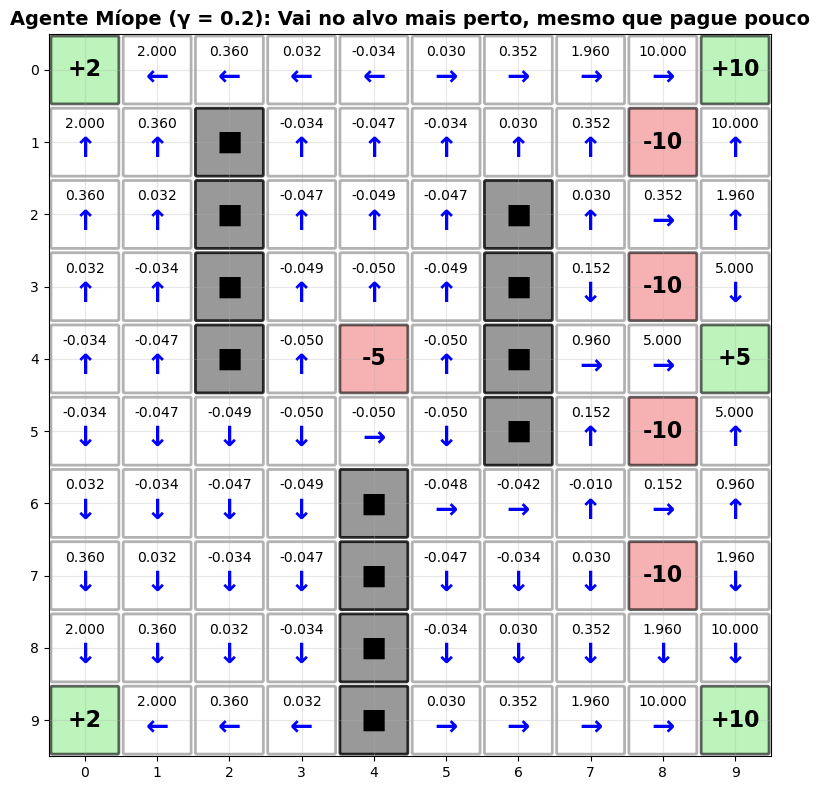

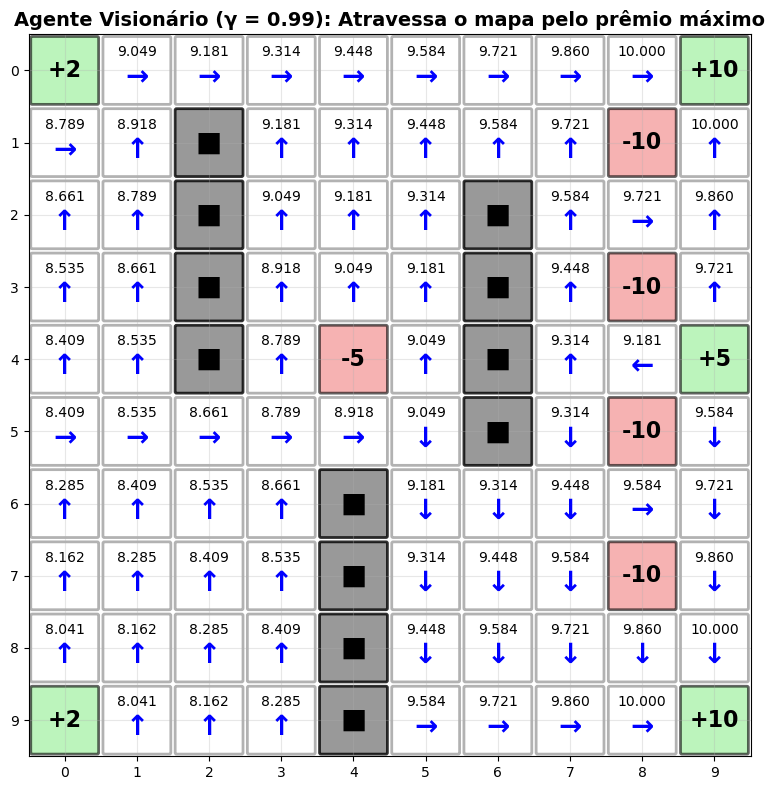

In [45]:
# Criando os dois cenários (Ruído 0.0 para isolar o efeito do Gama)
gw_miope = create_custom_gridworld(10, 10, paredes, terminais, gamma=0.2, noise=0.0)
gw_visionario = create_custom_gridworld(10, 10, paredes, terminais, gamma=0.99, noise=0.0)

# Resolvendo para o Agente Míope
V_miope, pi_miope, _ = value_iteration(gw_miope, gamma=0.2)

# Resolvendo para o Agente Visionário
V_visionario, pi_visionario, _ = value_iteration(gw_visionario, gamma=0.99)

# Visualizando lado a lado
visualize_gridworld(gw_miope, values=V_miope, policy=pi_miope, 
                    title="Agente Míope (γ = 0.2): Vai no alvo mais perto, mesmo que pague pouco", 
                    figsize=(10, 8))
plt.show()

visualize_gridworld(gw_visionario, values=V_visionario, policy=pi_visionario, 
                    title="Agente Visionário (γ = 0.99): Atravessa o mapa pelo prêmio máximo", 
                    figsize=(10, 8))
plt.show()

## 9. Experimento B: O Impacto do Ruído e a Aversão ao Risco

Agora vamos fixar o nosso fator de desconto como Visionário ($\gamma = 0.95$), mas vamos alterar a física do ambiente inserindo a estocasticidade de transição: o **Ruído**.

Na Equação de Bellman, o ruído é capturado pela distribuição de probabilidade $p(s'|s,a)$. 
Se o chão é de gelo escorregadio, tentar passar raspando por uma armadilha de $-10$ tem uma chance matemática de resultar em tragédia.

* **Ruído = 0.0 (Determinístico):** O agente tem 100% de controle. Ele é imprudente e passa colado nas armadilhas para encurtar o caminho.
* **Ruído = 0.3 (Altamente Estocástico):** O agente tem apenas 70% de chance de ir para onde quer. Ele se torna extremamente medroso, contornando o mapa bem longe dos $-10$, buscando rotas mais largas.

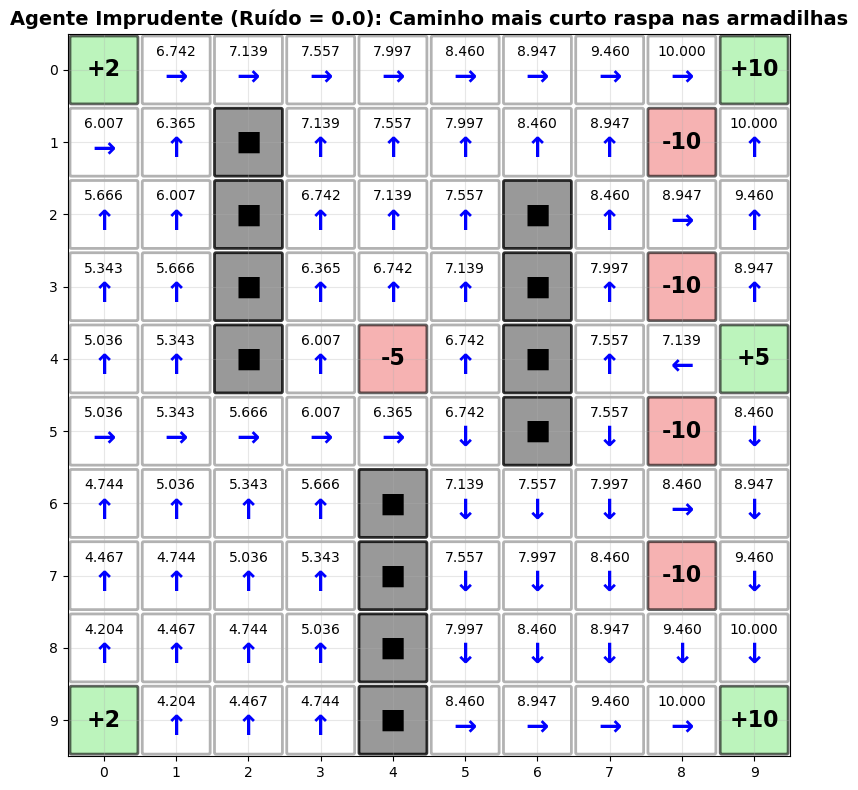

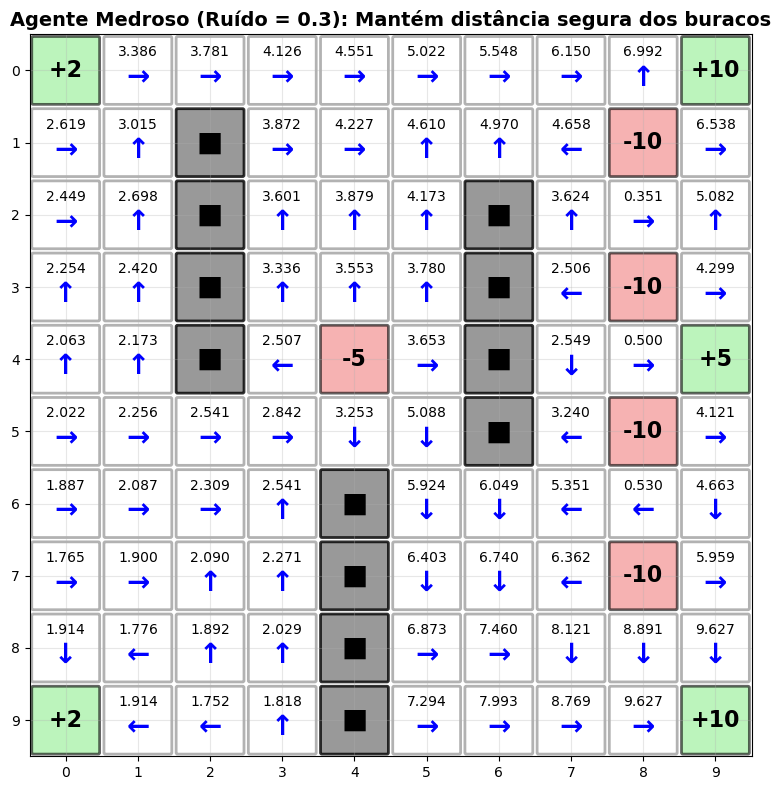

In [46]:
# Criando os dois cenários de Risco (Gama fixo em 0.95)
gw_imprudente = create_custom_gridworld(10, 10, paredes, terminais, gamma=0.95, noise=0.0)
gw_medroso = create_custom_gridworld(10, 10, paredes, terminais, gamma=0.95, noise=0.3)

# Resolvendo para o Agente Imprudente (Determinístico)
V_imprudente, pi_imprudente, _ = value_iteration(gw_imprudente, gamma=0.95)

# Resolvendo para o Agente Medroso (Estocástico)
V_medroso, pi_medroso, _ = value_iteration(gw_medroso, gamma=0.95)

# Visualizando os resultados
visualize_gridworld(gw_imprudente, values=V_imprudente, policy=pi_imprudente, 
                    title="Agente Imprudente (Ruído = 0.0): Caminho mais curto raspa nas armadilhas", 
                    figsize=(10, 8))
plt.show()

visualize_gridworld(gw_medroso, values=V_medroso, policy=pi_medroso, 
                    title="Agente Medroso (Ruído = 0.3): Mantém distância segura dos buracos", 
                    figsize=(10, 8))
plt.show()

## 10. O Experimento de Russell & Norvig: A Psicologia do Custo de Vida

No Aprendizado por Reforço, o agente não tem sentimentos ou moralidade; ele apenas segue a matemática da Função de Recompensa. O que acontece se alterarmos drasticamente o custo de dar um passo (o *living reward*) no nosso GridWorld clássico 4x3?

Vamos rodar a Equação de Otimalidade de Bellman para três psicologias diferentes:

1. **A Vida Normal ($R = -0.04$):** Viver tem um pequeno custo. O agente quer chegar ao objetivo (+1) rápido, mas não a ponto de cometer loucuras e arriscar cair no buraco (-1).
2. **O Desespero ($R = -2.0$):** A dor de existir é insuportável. Cada passo custa o dobro de cair na armadilha mortal. O agente preferirá se atirar no estado negativo mais próximo apenas para acabar com o episódio rapidamente.
3. **O Paraíso ($R = +0.1$):** Viver é lucrativo! O agente ganha pontos apenas por passear pelo mapa. Ele passará a fugir das saídas (tanto do +1 quanto do -1), pois terminar o jogo significa parar de ganhar pontos.

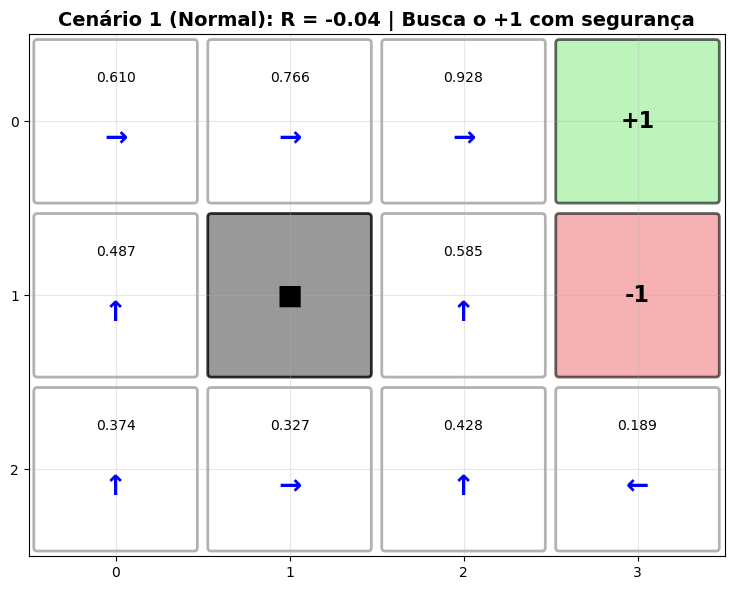

In [47]:
# Importando as funções necessárias
from environment import create_classic_gridworld
from algorithms import value_iteration
from visualization import visualize_gridworld
import matplotlib.pyplot as plt

# ==========================================
# CENÁRIO 1: A Vida Normal (R = -0.04)
# ==========================================
gw_normal = create_classic_gridworld()
# O valor padrão já é -0.04, então apenas rodamos o algoritmo
V_norm, pi_norm, _ = value_iteration(gw_normal, gamma=0.9, theta=1e-5)

visualize_gridworld(
    gw_normal, 
    values=V_norm, 
    policy=pi_norm, 
    title="Cenário 1 (Normal): R = -0.04 | Busca o +1 com segurança",
    figsize=(8, 6)
)
plt.show()

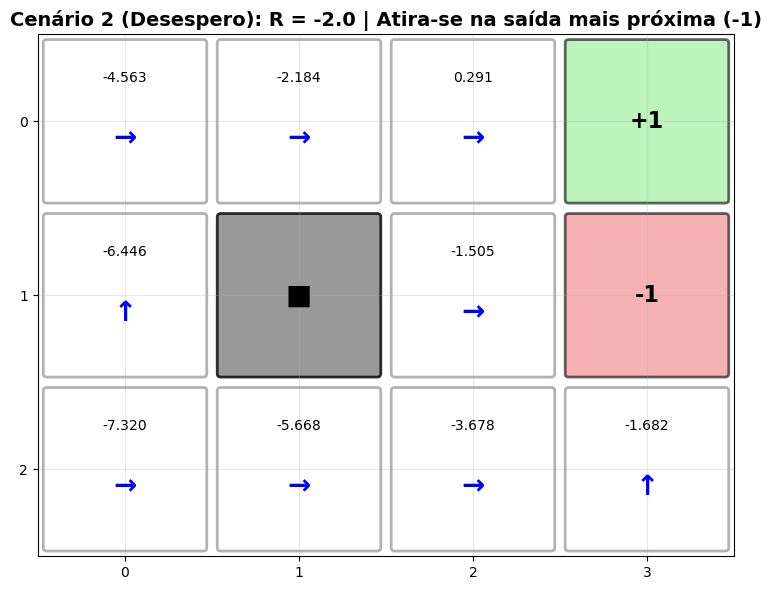

In [48]:
# ==========================================
# CENÁRIO 2: O Desespero / Suicida (R = -2.0)
# ==========================================
gw_suicida = create_classic_gridworld()
gw_suicida.living_reward = -2.0
gw_suicida.build_model() # IMPORTANTE: Recalcula a matriz de transição com o novo R

V_sui, pi_sui, _ = value_iteration(gw_suicida, gamma=0.9, theta=1e-5)

visualize_gridworld(
    gw_suicida, 
    values=V_sui, 
    policy=pi_sui, 
    title="Cenário 2 (Desespero): R = -2.0 | Atira-se na saída mais próxima (-1)",
    figsize=(8, 6)
)
plt.show()

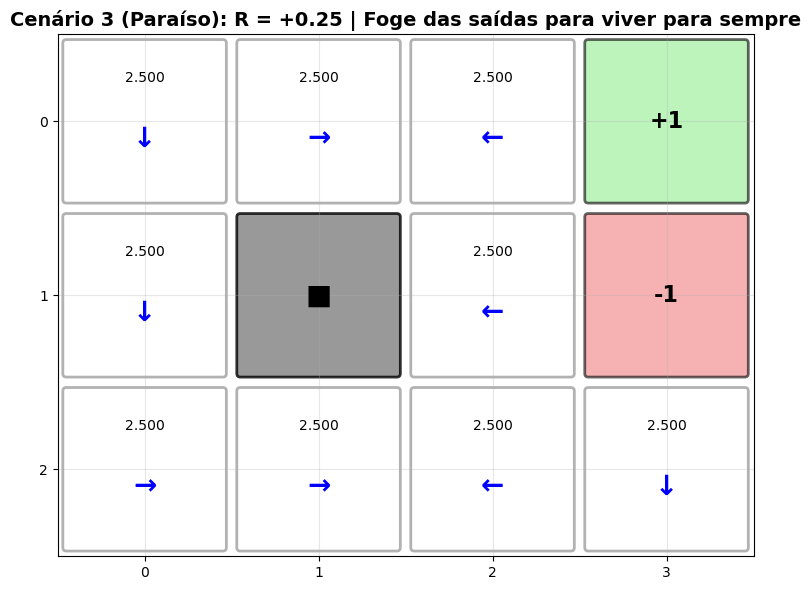

In [49]:
# ==========================================
# CENÁRIO 3: O Paraíso (R = +0.25)
# ==========================================
gw_paraiso = create_classic_gridworld()
gw_paraiso.living_reward = 0.25
gw_paraiso.build_model() # IMPORTANTE: Recalcula a matriz de transição com o novo R

V_par, pi_par, _ = value_iteration(gw_paraiso, gamma=0.9, theta=1e-5)

visualize_gridworld(
    gw_paraiso, 
    values=V_par, 
    policy=pi_par, 
    title="Cenário 3 (Paraíso): R = +0.25 | Foge das saídas para viver para sempre",
    figsize=(8, 6)
)
plt.show()

## 11. Variante do Paraíso: E se o prêmio final for decepcionante?

No experimento anterior, vimos que com um custo de vida positivo ($R = +0.1$), o agente prefere não terminar o jogo. 

Nesta variante, vamos manter o custo de vida em $+0.1$, mas vamos **reduzir a recompensa do estado terminal positivo de $+1.0$ para $+0.5$**.

**A Hipótese:** A matemática do limite infinito com $\gamma = 0.9$ diz que receber $+0.1$ para sempre vale $1.0$. Se o prêmio de saída for apenas $+0.5$, terminar o jogo torna-se um péssimo negócio financeiro para o agente. Veremos uma política ainda mais agressiva de fuga das bordas, com o agente tentando se "esconder" no canto inferior esquerdo para minimizar qualquer chance estocástica de cair acidentalmente nos terminais.

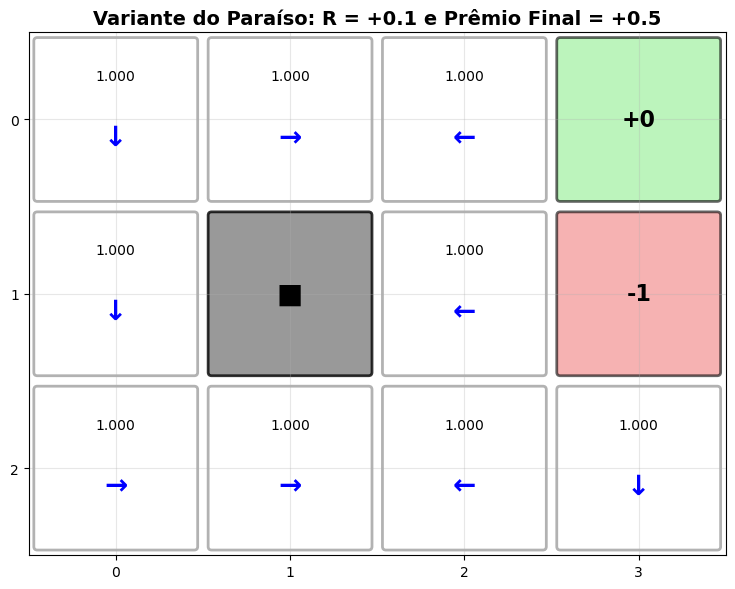

Valores dos estados próximos aos terminais:
Estado (0,2) [Vizinho esquerdo do prêmio]: 1.000
Estado (1,2) [Vizinho esquerdo do buraco]: 1.000


In [52]:
# Importando as funções necessárias caso este bloco seja rodado isoladamente
from environment import create_classic_gridworld
from algorithms import value_iteration
from visualization import visualize_gridworld
import matplotlib.pyplot as plt

# Criando o ambiente base
gw_variante = create_classic_gridworld()

# 1. Definimos o custo de vida positivo (O Paraíso)
gw_variante.living_reward = 0.1

# 2. Reduzimos o valor do estado terminal positivo (linha 0, coluna 3) de 1.0 para 0.5
gw_variante.set_terminal(0, 3, 0.5)

# IMPORTANTE: Sempre que alteramos a física ou as regras do mundo, precisamos reconstruir o modelo
gw_variante.build_model()

# Executando o Value Iteration
V_var, pi_var, _ = value_iteration(gw_variante, gamma=0.9, theta=1e-5)

# Visualizando o comportamento
visualize_gridworld(
    gw_variante, 
    values=V_var, 
    policy=pi_var, 
    title="Variante do Paraíso: R = +0.1 e Prêmio Final = +0.5",
    figsize=(8, 6)
)
plt.show()

# Imprimindo os valores calculados para os estados vizinhos à saída
print("Valores dos estados próximos aos terminais:")
print(f"Estado (0,2) [Vizinho esquerdo do prêmio]: {V_var[0 * gw_variante.cols + 2]:.3f}")
print(f"Estado (1,2) [Vizinho esquerdo do buraco]: {V_var[1 * gw_variante.cols + 2]:.3f}")

## 12. Pânico no Paraíso: O Peso Extremo da Incerteza

O que acontece se o agente estiver no "Paraíso" ($R = +0.1$), mas o chão for feito de gelo extremamente escorregadio? 

Neste experimento, vamos aumentar a Incerteza (Ruído) do ambiente clássico de 20% para **50%**. Isso significa que metade das vezes em que o agente tentar ir para a frente, ele vai deslizar para a esquerda ou para a direita.

**A Hipótese:** Como o agente quer viver para sempre para acumular $+0.1$ infinitamente, ele ficará aterrorizado com a possibilidade de escorregar sem querer para o $+1$ ou para o $-1$, pois ambos encerram o jogo. A Equação de Bellman fará com que o agente fuja para o canto mais distante possível das saídas e aponte para a parede, usando-a como um "freio" para se manter no lugar com segurança.

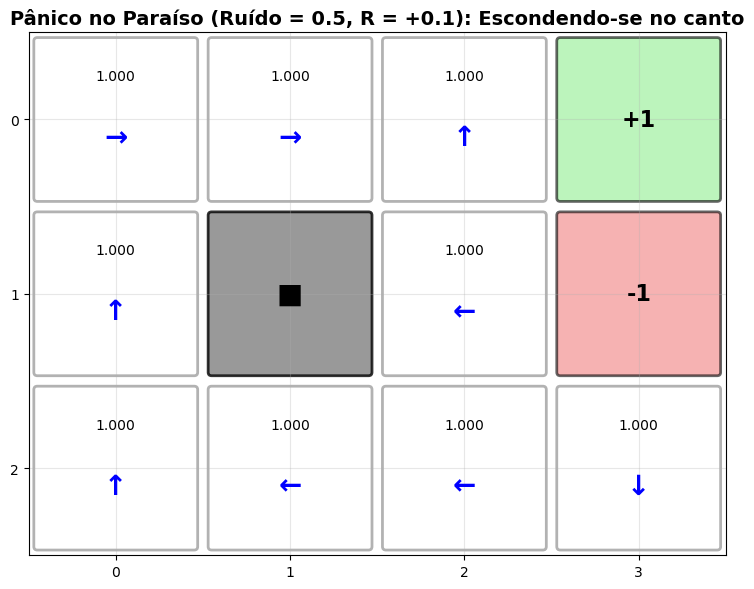

In [53]:
# Importando as funções (caso rode isoladamente)
from environment import create_classic_gridworld
from algorithms import value_iteration
from visualization import visualize_gridworld
import matplotlib.pyplot as plt

# Criando o ambiente base
gw_panico = create_classic_gridworld()

# 1. Vida lucrativa (Paraíso)
gw_panico.living_reward = 0.1

# 2. Aumentando o ruído de 0.2 para 0.5 (50% de chance de escorregar para os lados)
gw_panico.noise = 0.5

# IMPORTANTE: Reconstruindo a matemática do modelo após alterar a física do mundo
gw_panico.build_model()

# Rodando o Value Iteration
V_panico, pi_panico, _ = value_iteration(gw_panico, gamma=0.9, theta=1e-5)

# Visualizando o pânico
visualize_gridworld(
    gw_panico, 
    values=V_panico, 
    policy=pi_panico, 
    title="Pânico no Paraíso (Ruído = 0.5, R = +0.1): Escondendo-se no canto",
    figsize=(8, 6)
)
plt.show()

### Análise: O Comportamento de "Freio na Parede"

Analise as setas no gráfico gerado. Preste atenção especial na coluna mais à esquerda (a coluna 0):

Em vez de andar para cima ou para baixo, a política ótima manda o agente **apontar diretamente para a borda esquerda do mapa (Oeste)**. 

Por que ele faz isso?
No nosso GridWorld, se o agente tenta ir em direção a uma parede ou limite do mapa, ele "bate" e fica no mesmo lugar. Com um ruído de 50%, a ação mais segura que existe para não ser arrastado pelo gelo é forçar o movimento contra uma parede contínua. 

A matemática (Equação de Otimalidade) não sente medo, ela apenas calcula probabilidades. Ela determinou que o valor esperado de ficar se jogando contra a parede esquerda rende um fluxo contínuo e seguro de $+0.1$, isolando o agente de qualquer probabilidade estocástica de cair na coluna 3 (onde o jogo acaba).

## 13. Aplicação Real: Roteamento de Robô de Inspeção Industrial

Até agora, tratamos o GridWorld como um jogo. Mas na ciência de dados aplicada, ele é uma matriz matemática que mapeia espaços físicos ou lógicos.

Vamos modelar o planejamento de rota de um robô de inspeção dentro de uma **Usina de Biogás / Rede de Gás Natural**.

* **O Espaço:** Uma planta industrial de 8x8 zonas.
* **Obstáculos (Paredes):** Tanques de gás e tubulações que o robô precisa contornar.
* **Meta (+100):** A válvula de pressão crítica que precisa de manutenção imediata no canto superior direito.
* **Perigo (-100):** Uma zona com detecção de vazamento de gás tóxico/inflamável no centro da planta. Se o robô entrar lá, seus circuitos podem causar uma faísca ou ele será perdido.
* **Custo Operacional (-1):** Consumo de bateria por cada movimento.
* **A Incerteza (Ruído = 0.15):** O chão industrial tem poças de óleo. Há 15% de chance de o robô derrapar para o lado ao tentar andar em linha reta.

Vamos usar a Programação Dinâmica para garantir que o robô encontre a rota mais segura e eficiente, sem risco de explodir a usina.

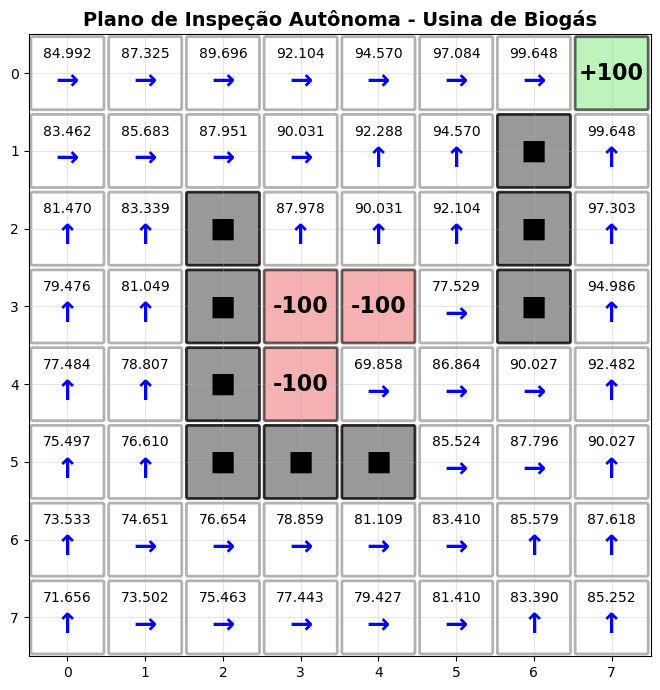

In [54]:
from environment import create_custom_gridworld

# 1. Mapeando a Planta Industrial (8x8)
# Tubulações e Tanques (Paredes)
tubulacoes = [
    (2,2), (3,2), (4,2), (5,2), # Tubulação vertical
    (5,3), (5,4),               # Curva da tubulação
    (1,6), (2,6), (3,6)         # Tanque de armazenamento
]

# Pontos de Interesse (Terminais)
zonas_criticas = {
    (0, 7): 100.0,   # Válvula Crítica (Objetivo)
    (3, 3): -100.0,  # Vazamento de Gás 1 (Perigo Mortal)
    (3, 4): -100.0,  # Vazamento de Gás 2 (Perigo Mortal)
    (4, 3): -100.0   # Vazamento de Gás 3 (Perigo Mortal)
}

# 2. Criando o Gêmeo Digital do Ambiente
planta_biogas = create_custom_gridworld(
    rows=8, cols=8, 
    walls=tubulacoes, 
    terminals=zonas_criticas,
    gamma=0.99,       # Robô planeja a longo prazo
    noise=0.15,       # 15% de chance de derrapar no piso industrial
    living_reward=-1.0 # Custo de bateria por movimento
)

# 3. Calculando a Rota Ótima com Value Iteration
V_robo, pi_robo, _ = value_iteration(planta_biogas, gamma=0.99, theta=1e-5)

# 4. Visualizando o Plano de Ação do Robô
visualize_gridworld(
    planta_biogas, 
    values=V_robo, 
    policy=pi_robo, 
    title="Plano de Inspeção Autônoma - Usina de Biogás",
    figsize=(9, 7)
)
plt.show()

### Análise da Rota Industrial

Ao visualizar a política (as setas de direção), note a inteligência incorporada na tomada de decisão do robô:

1. **Eficiência de Bateria:** Nas áreas abertas e seguras, as setas apontam pelo caminho mais direto possível até a válvula crítica, minimizando o custo de bateria ($-1$).
2. **Margem de Segurança:** Observe os estados imediatamente adjacentes à zona de vazamento de gás (os quadrados de $-100$). A política manda o robô "dar as costas" para o vazamento ou apontar para as paredes seguras quando está muito perto. A Equação de Bellman calculou que o risco de derrapar (15%) e cair no vazamento é inaceitável, forçando o robô a fazer curvas mais abertas.

É assim que algoritmos de aprendizado por reforço são usados para planejar missões de hardware no mundo real!

# Lista de Exercícios Práticos: Programação Dinâmica e MDPs

Esta lista de exercícios tem como objetivo fixar os conceitos de Processos de Decisão de Markov (MDPs) e a aplicação da Equação de Bellman através dos algoritmos de Programação Dinâmica. Use as funções dos módulos `environment`, `algorithms` e `visualization` para resolver os problemas.

## Exercício 1 (Fácil): O Labirinto Básico
**Objetivo:** Praticar a criação de ambientes customizados e a extração da Política Ótima.

**Tarefa:** 1. Crie um ambiente customizado de 5 linhas por 5 colunas.
2. Defina um único estado terminal positivo com recompensa $+10$ na posição (4, 4).
3. Adicione uma parede diagonal cortando o mapa nas posições: (1,1), (2,2) e (3,3).
4. Mantenha os valores padrão de fator de desconto ($\gamma = 0.9$) e ruído ($0.2$).
5. Execute o algoritmo *Value Iteration* e plote o resultado. O agente consegue encontrar o caminho contornando a parede?

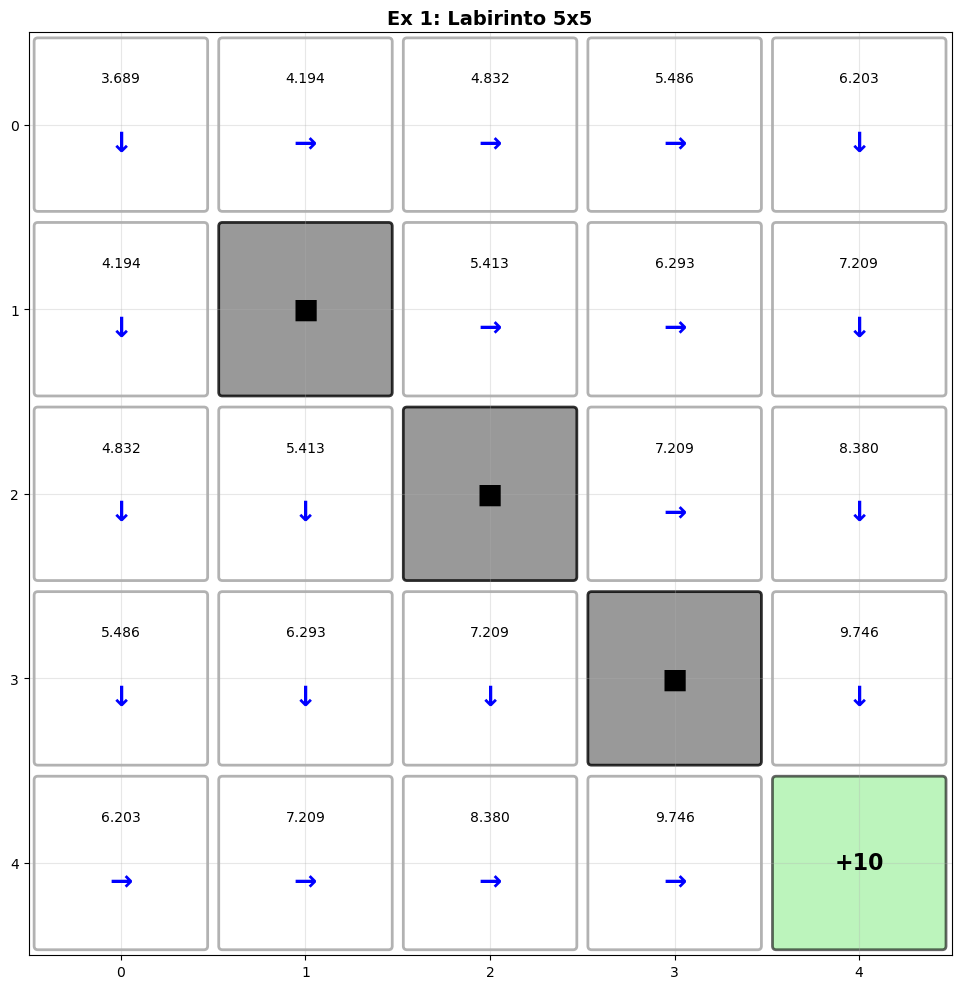

In [61]:
# Sua resposta aqui

# GABARITO - EXERCÍCIO 1: O Labirinto Básico
from environment import create_custom_gridworld
from algorithms import value_iteration
from visualization import visualize_gridworld
import matplotlib.pyplot as plt

# 1. Definindo as configurações
paredes = [(1,1), (2,2), (3,3)]
terminais = {(4,4): 10.0}

# 2. Criando o ambiente 5x5
gw_ex1 = create_custom_gridworld(
    rows=5, cols=5, 
    walls=paredes, 
    terminals=terminais
)

# 3. Rodando Value Iteration
V_ex1, pi_ex1, _ = value_iteration(gw_ex1)

# 4. Visualizando
visualize_gridworld(gw_ex1, values=V_ex1, policy=pi_ex1, title="Ex 1: Labirinto 5x5")
plt.show()

## Exercício 2 (Médio): O Agente Apressado vs. O Agente Paciente
**Objetivo:** Observar o impacto do Fator de Desconto ($\gamma$) no comportamento de longo prazo.

**Tarefa:**
Vamos usar o GridWorld Clássico (4x3). Você deve instanciar dois ambientes idênticos, mas com fatores de desconto diferentes ao rodar o *Value Iteration*:
1. **Agente Apressado/Míope:** Resolva o ambiente usando $\gamma = 0.1$.
2. **Agente Paciente/Visionário:** Resolva o ambiente usando $\gamma = 0.99$.
3. Plote os dois resultados lado a lado. 
**Pergunta:** O que acontece com a política do Agente Apressado em estados que estão longe do objetivo $+1$? Por que ele toma essa decisão?

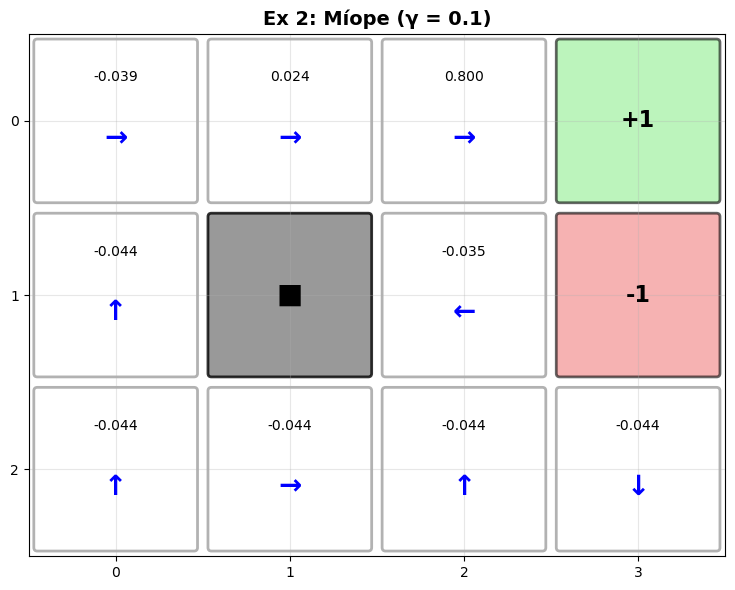

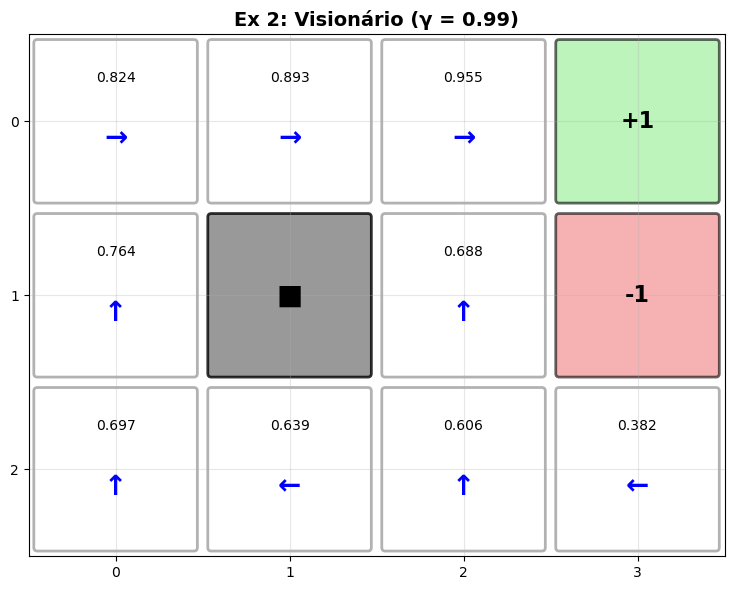

In [62]:
# Sua resposta aqui

# GABARITO - EXERCÍCIO 2: Agente Apressado vs Paciente
from environment import create_classic_gridworld

gw_ex2 = create_classic_gridworld()

# Agente Apressado (Gama = 0.1)
V_apressado, pi_apressado, _ = value_iteration(gw_ex2, gamma=0.1)
visualize_gridworld(gw_ex2, values=V_apressado, policy=pi_apressado, title="Ex 2: Míope (γ = 0.1)")
plt.show()

# Agente Paciente (Gama = 0.99)
V_paciente, pi_paciente, _ = value_iteration(gw_ex2, gamma=0.99)
visualize_gridworld(gw_ex2, values=V_paciente, policy=pi_paciente, title="Ex 2: Visionário (γ = 0.99)")
plt.show()

## Exercício 3 (Difícil): O Chão de Gelo no CliffWorld
**Objetivo:** Analisar como o ruído (estocasticidade) altera a percepção de risco.

**Tarefa:**
Utilize a função `create_cliff_world_2` (4x8) para criar três cenários de risco. Para cada cenário, extraia a política ótima com *Value Iteration* e plote o gráfico:
1. **Cenário Determinístico:** Ruído de 0.0.
2. **Cenário Escorregadio:** Ruído de 0.2.
3. **Cenário Caótico:** Ruído de 0.5.
**Pergunta:** Como a rota ótima muda conforme a incerteza aumenta? Onde o agente tenta se abrigar no cenário caótico?

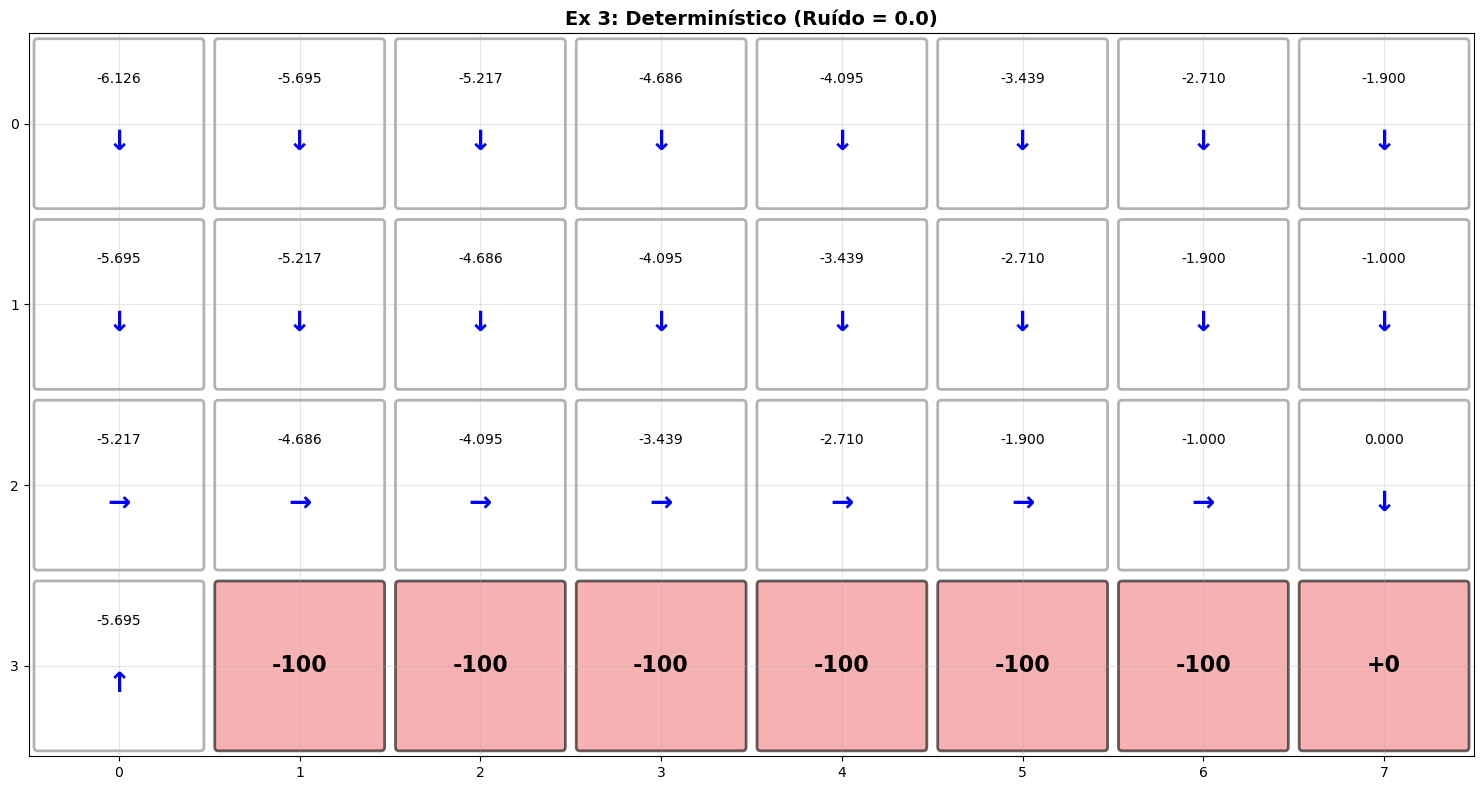

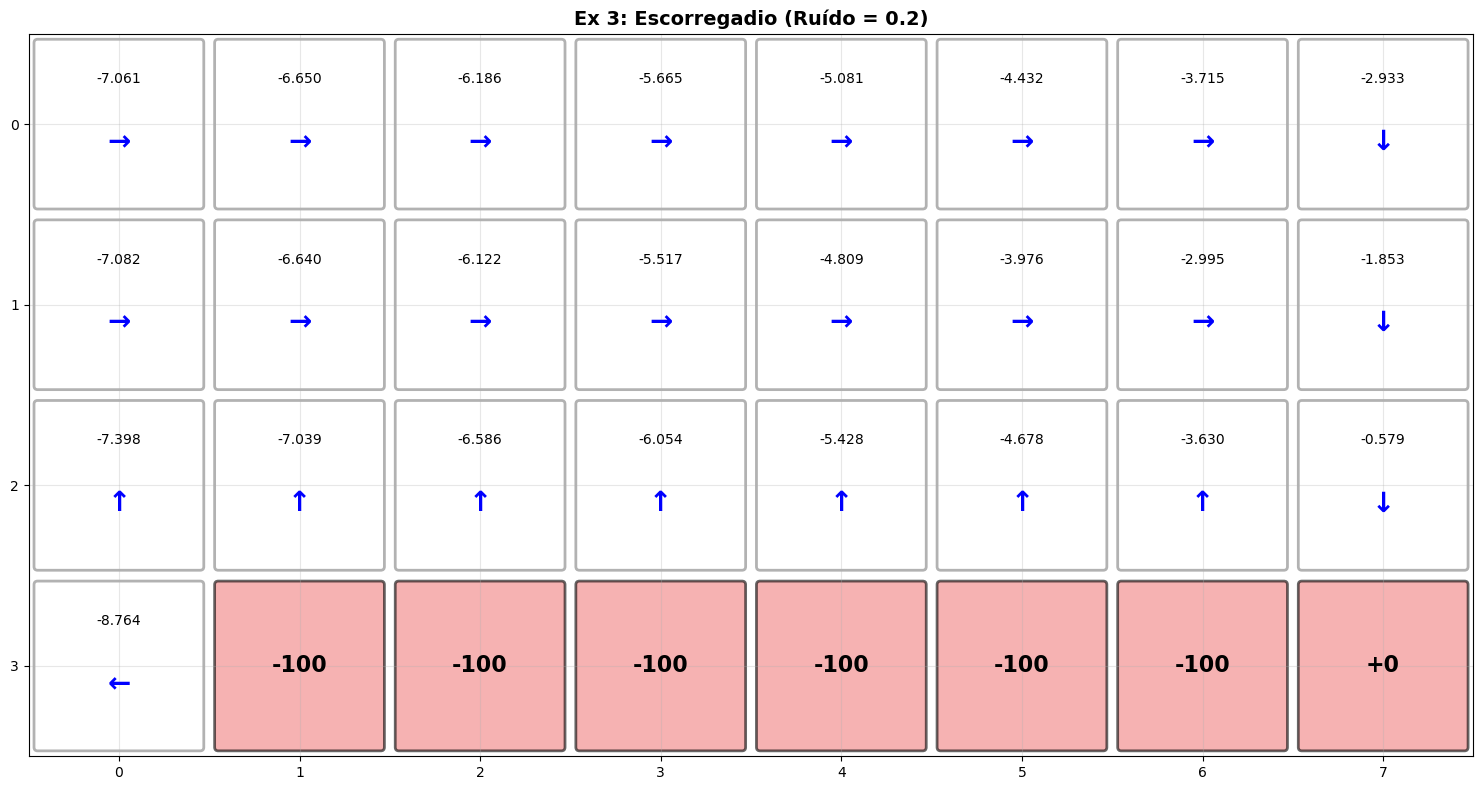

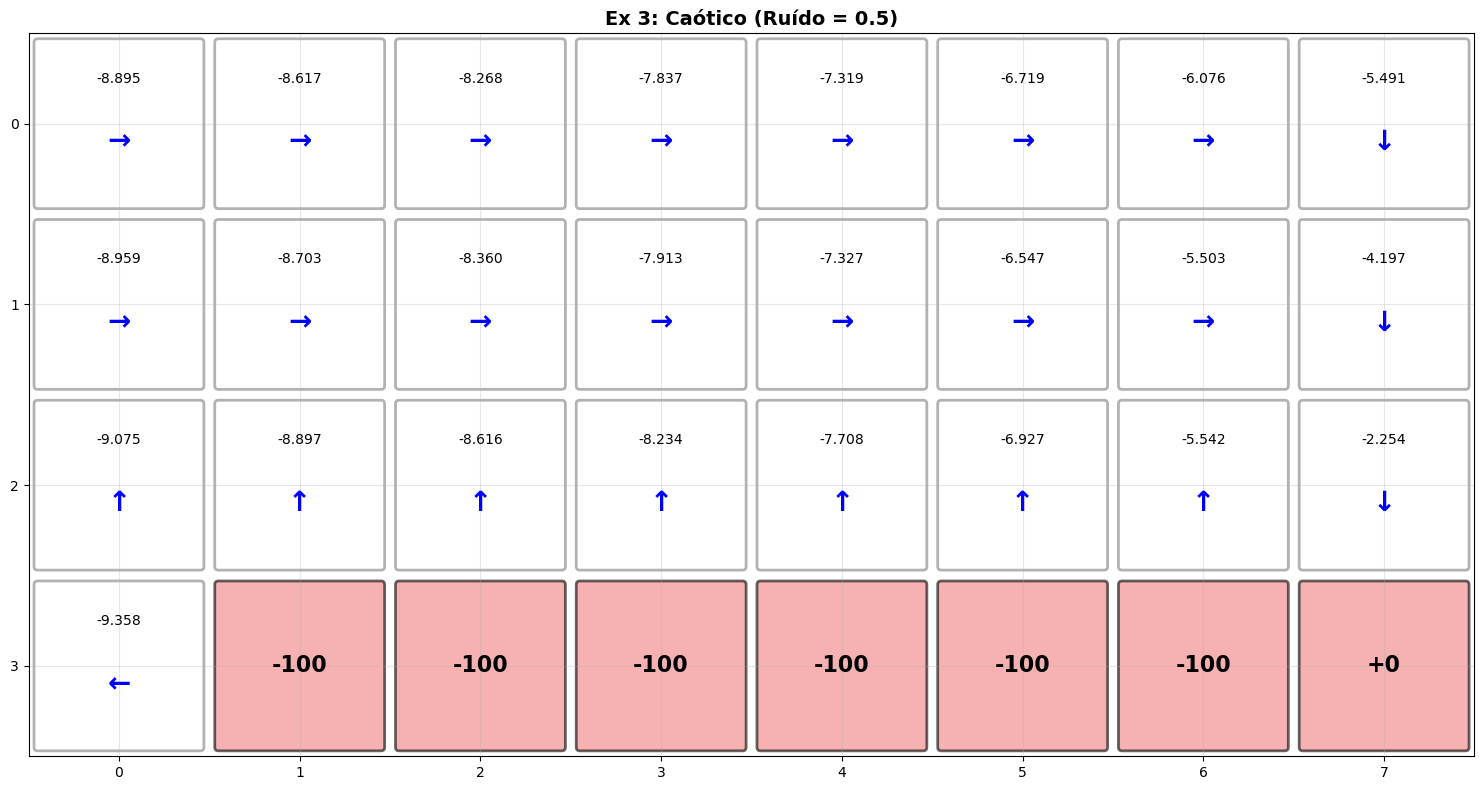

In [65]:
# Sua resposta aqui

# GABARITO - EXERCÍCIO 3: O Chão de Gelo no CliffWorld
from environment import create_cliff_world_2

# 1. Determinístico (Ruído = 0.0)
gw_det = create_cliff_world_2(noise=0.0)
V_det, pi_det, _ = value_iteration(gw_det)
visualize_gridworld(gw_det, values=V_det, policy=pi_det, title="Ex 3: Determinístico (Ruído = 0.0)")
plt.show()

# 2. Escorregadio (Ruído = 0.2)
gw_esco = create_cliff_world_2(noise=0.2)
V_esco, pi_esco, _ = value_iteration(gw_esco)
visualize_gridworld(gw_esco, values=V_esco, policy=pi_esco, title="Ex 3: Escorregadio (Ruído = 0.2)")
plt.show()

# 3. Caótico (Ruído = 0.5)
gw_caos = create_cliff_world_2(noise=0.5)
V_caos, pi_caos, _ = value_iteration(gw_caos)
visualize_gridworld(gw_caos, values=V_caos, policy=pi_caos, title="Ex 3: Caótico (Ruído = 0.5)")
plt.show()

## Exercício 4 (Desafio): Batalha de Algoritmos (Value Iteration vs. Policy Iteration)
**Objetivo:** Comparar a velocidade de convergência entre os dois principais algoritmos de Programação Dinâmica.

**Tarefa:**
Crie um ambiente customizado grande (ex: 8x8) com algumas paredes e terminais da sua escolha. 
1. Resolva o MDP usando `value_iteration` e guarde o histórico de erros (deltas).
2. Resolva o mesmo MDP usando `policy_iteration` e guarde o histórico de mudanças na política.
3. Imprima a quantidade de iterações (passos) que cada algoritmo precisou para convergir. 
**Dica:** Verifique se as matrizes de valor $V^*(s)$ geradas por ambos são idênticas.

In [80]:
# GABARITO - EXERCÍCIO 4: Batalha de Algoritmos
from algorithms import policy_iteration
import numpy as np

# Criando um ambiente 8x8 simples
gw_ex4 = create_custom_gridworld(
    rows=8, cols=8, 
    walls=[(4,0), (4,1), (4,2), (4,3)], 
    terminals={
        (7,7): 10.0, 
        (7,0): -100.0, 
        #(0,7): 10.0, 
        (0,0): -100.0
    }
)

gw_ex4.noise = 0.7

# Rodando Value Iteration
V_vi, pi_vi, deltas = value_iteration(gw_ex4)

# Rodando Policy Iteration
V_pi, pi_pi, evals, changes = policy_iteration(gw_ex4)

print("="*50)
print("RESULTADOS DA BATALHA DE ALGORITMOS")
print("="*50)
print(f"Value Iteration precisou de {len(deltas)} iterações completas.")
print(f"Policy Iteration precisou de {len(changes)} passos de melhoria de política.")

# Verificando se as respostas matemáticas batem
diferenca = np.max(np.abs(V_vi - V_pi))
if diferenca < 1e-4:
    print("\nSUCESSO: Ambos os algoritmos encontraram o mesmo Valor Ótimo V*(s)!")
else:
    print("\nAVISO: Divergência nos resultados.")

RESULTADOS DA BATALHA DE ALGORITMOS
Value Iteration precisou de 22 iterações completas.
Policy Iteration precisou de 4 passos de melhoria de política.

AVISO: Divergência nos resultados.


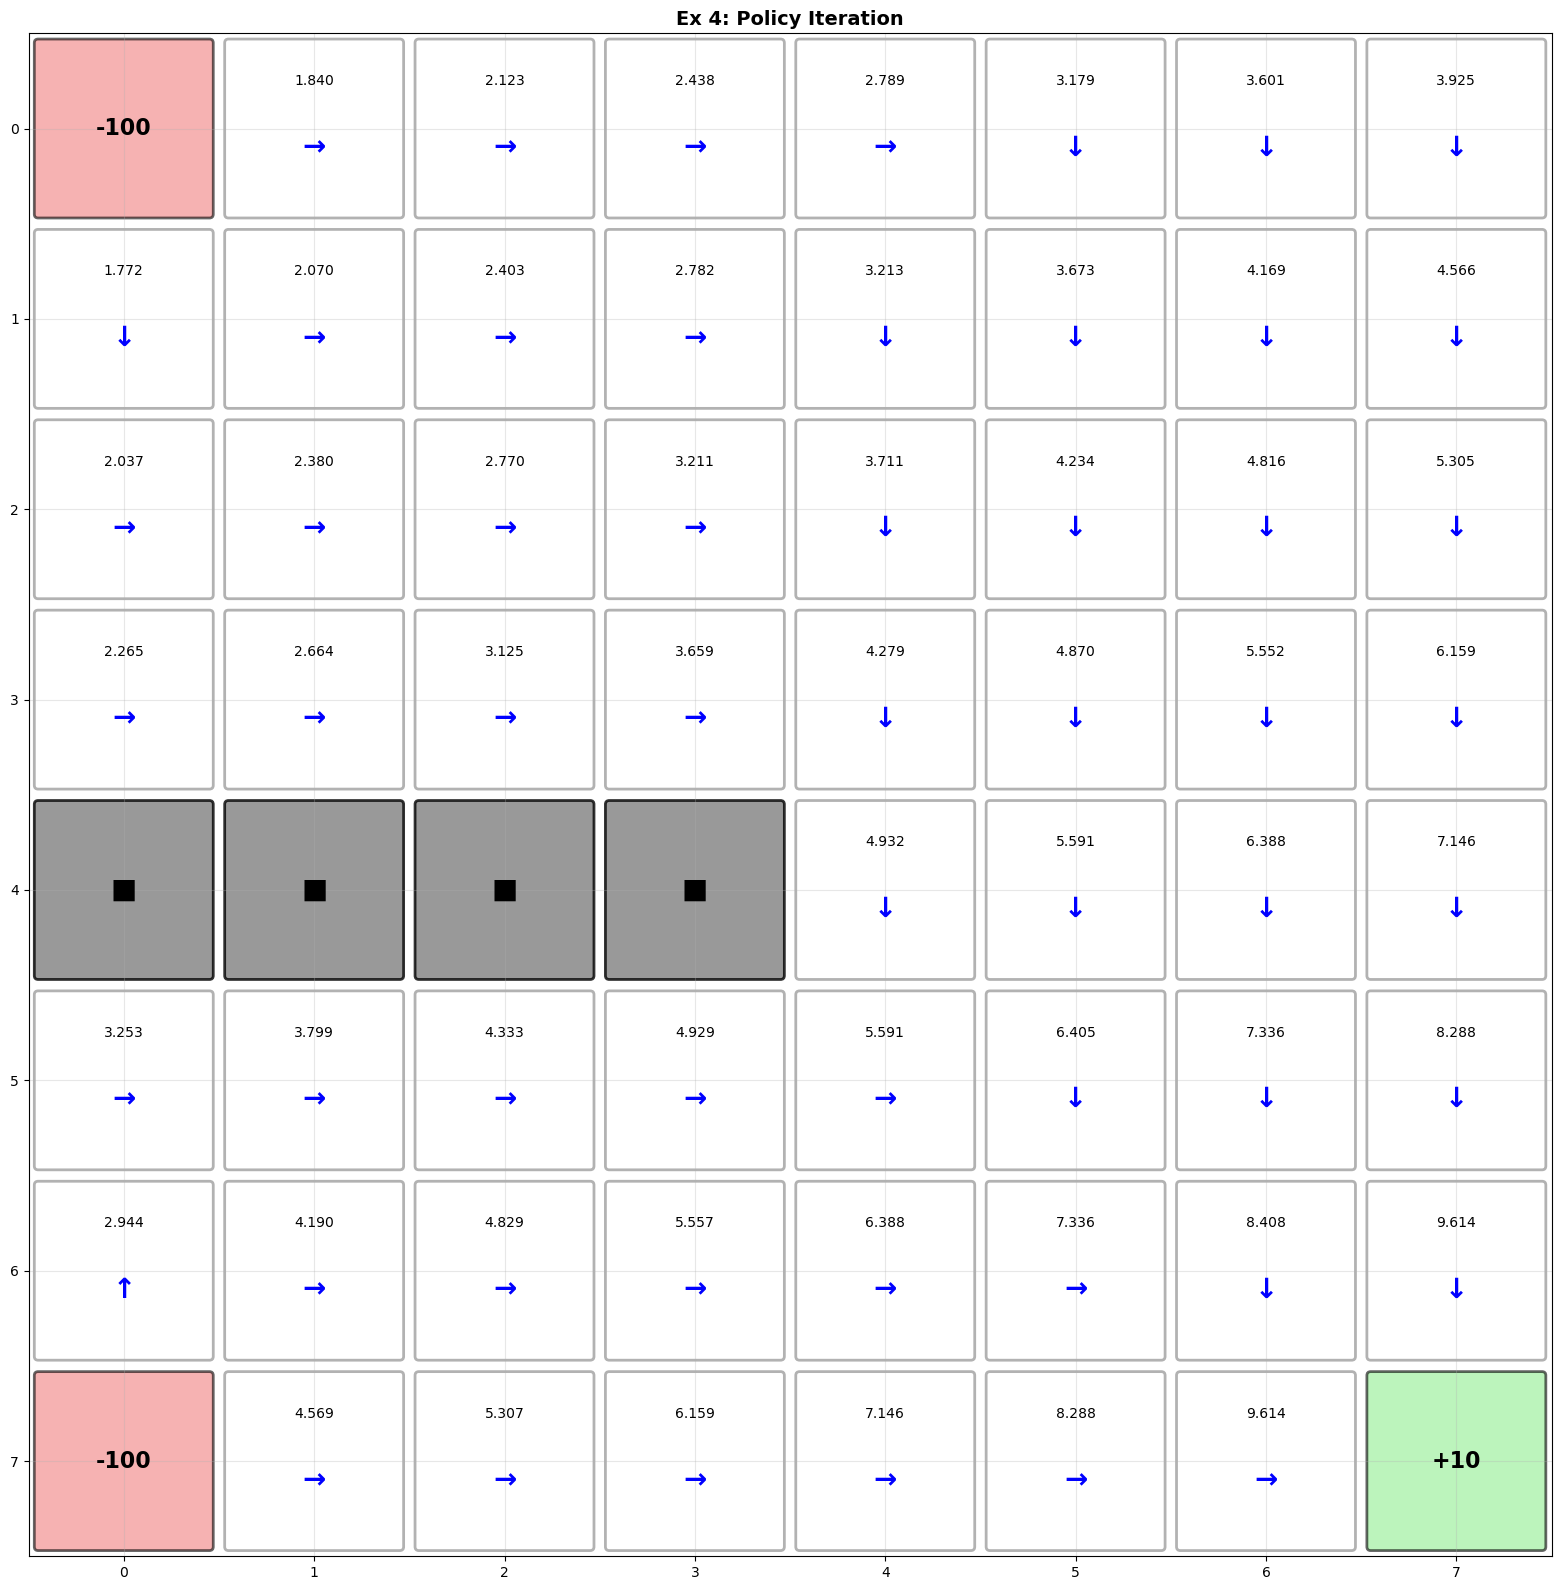

In [81]:
visualize_gridworld(gw_ex4, values=V_pi, policy=pi_pi, title="Ex 4: Policy Iteration")

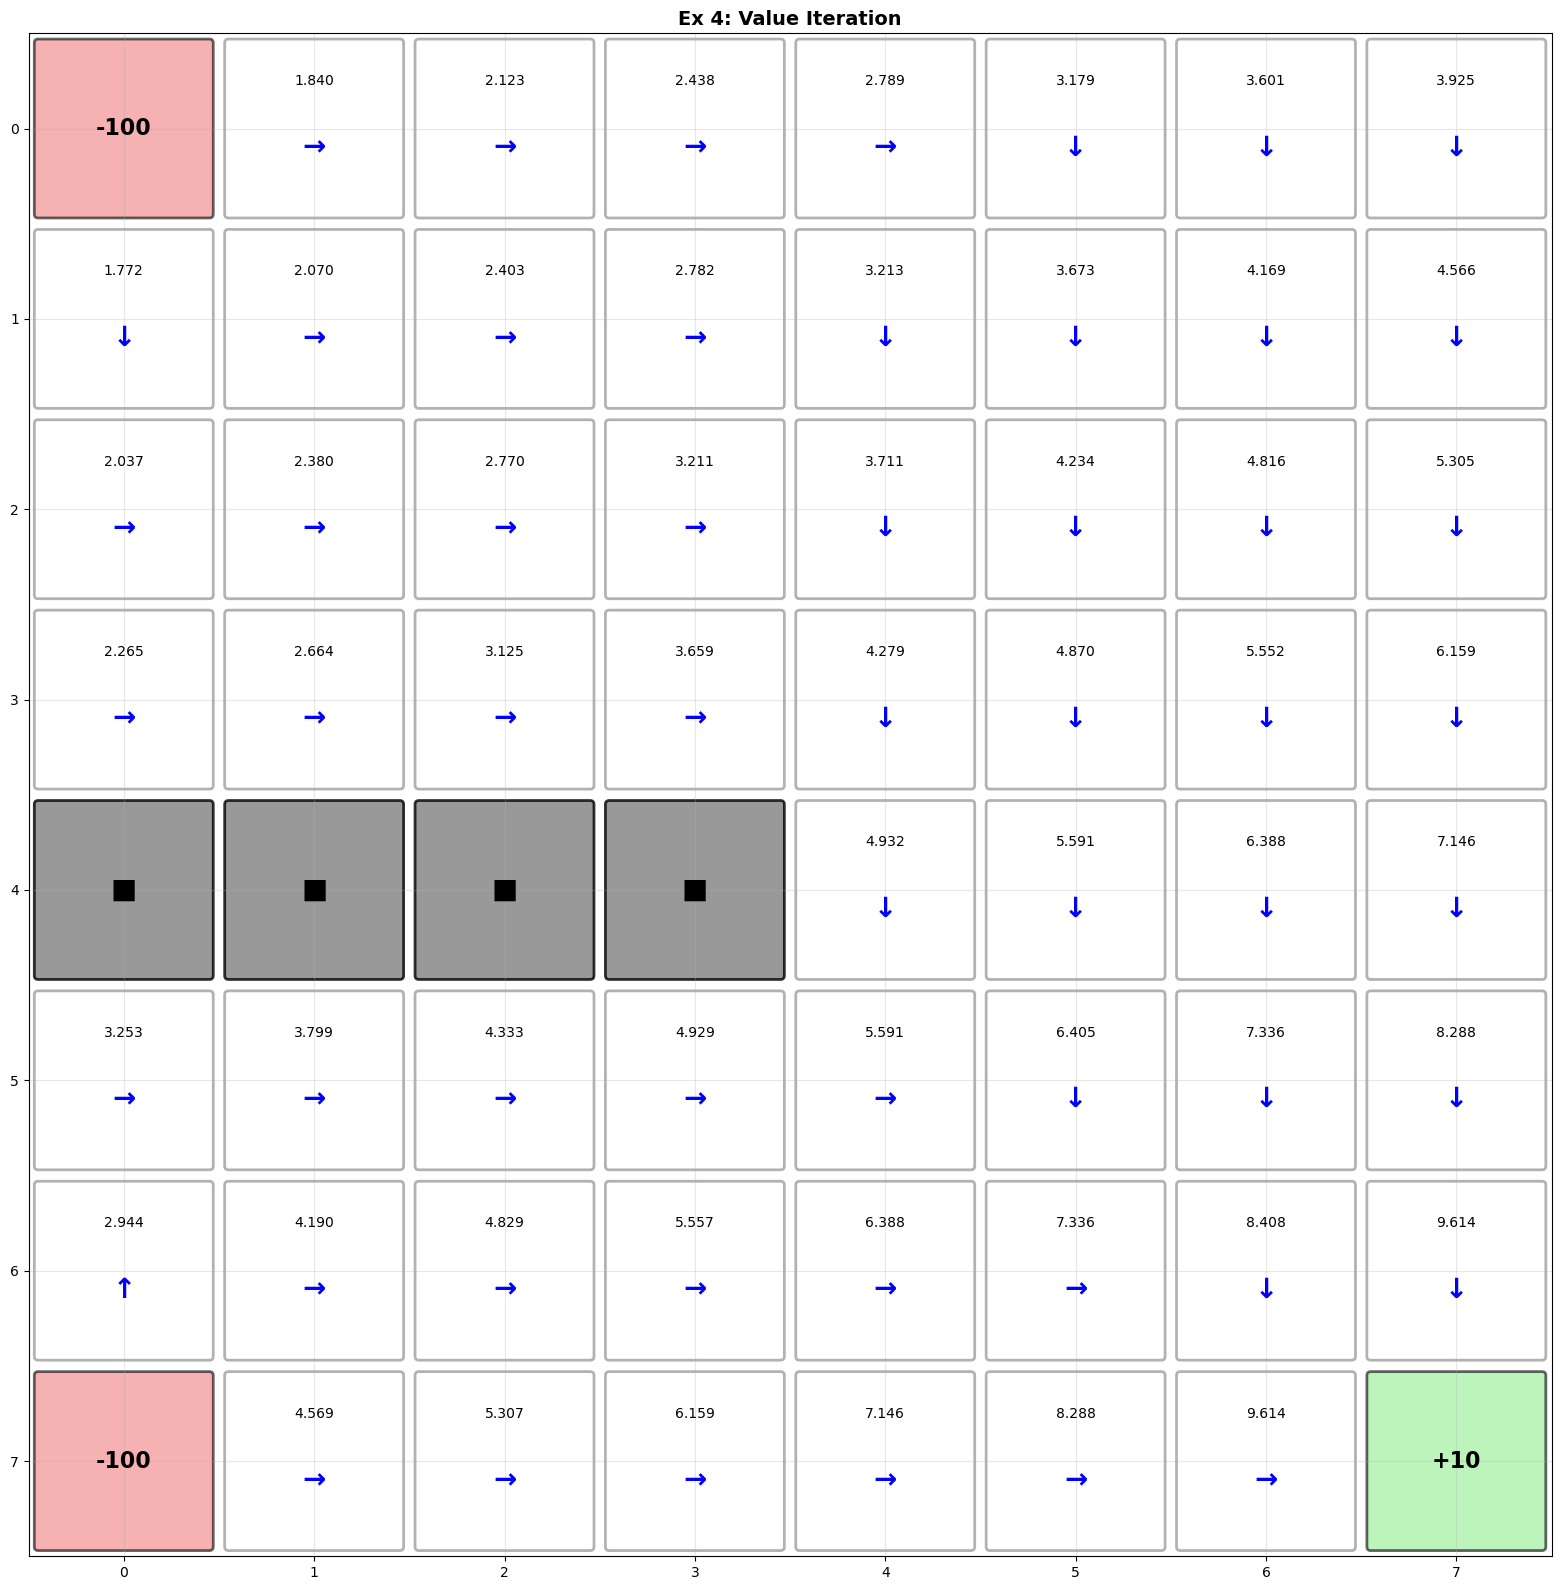

In [82]:
visualize_gridworld(gw_ex4, values=V_vi, policy=pi_vi, title="Ex 4: Value Iteration")

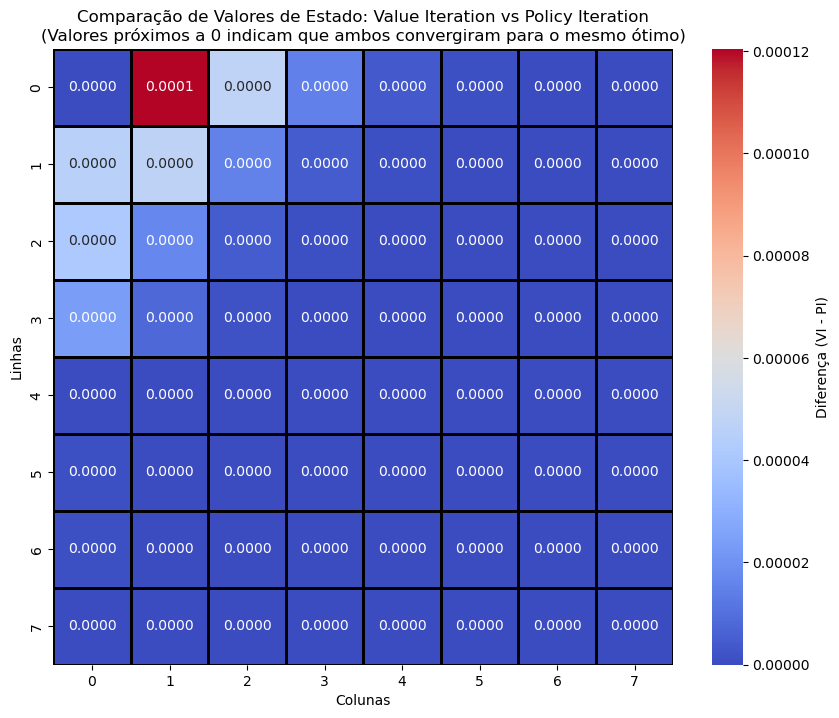

Maior divergência absoluta encontrada: 0.00012049
Conclusão: Os algoritmos pararam em valores de utilidade diferentes (Verifique o critério de parada 'theta').


In [83]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Calculando a diferença (Value Iteration - Policy Iteration)
# Se o resultado for positivo, VI achou um valor maior.
# Se for negativo, PI achou um valor maior.
# Se for zero, ambos concordam perfeitamente.
diferenca_valores = V_vi - V_pi

# O Grid do Exercício 4 é 8x8. Precisamos remodelar o array 1D para uma matriz 2D
grid_shape = (gw_ex4.rows, gw_ex4.cols)
matriz_diferenca = diferenca_valores.reshape(grid_shape)

# Configurando o Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_diferenca, 
    annot=True,          # Mostra os números dentro das células
    fmt=".4f",           # Formata para 4 casas decimais
    cmap="coolwarm",     # Azul para negativo, Vermelho para positivo, Branco para zero
    cbar_kws={'label': 'Diferença (VI - PI)'},
    linewidths=1,
    linecolor='black'
)

plt.title("Comparação de Valores de Estado: Value Iteration vs Policy Iteration\n(Valores próximos a 0 indicam que ambos convergiram para o mesmo ótimo)")
plt.xlabel("Colunas")
plt.ylabel("Linhas")
plt.show()

# Análise estatística da diferença
erro_maximo = np.max(np.abs(diferenca_valores))
print(f"Maior divergência absoluta encontrada: {erro_maximo:.8f}")
if erro_maximo < 1e-4:
    print("Conclusão: As diferenças são apenas erros residuais de ponto flutuante. Ambos convergiram para V*.")
else:
    print("Conclusão: Os algoritmos pararam em valores de utilidade diferentes (Verifique o critério de parada 'theta').")

COMPARAÇÃO VISUAL DAS POLÍTICAS ÓTIMAS


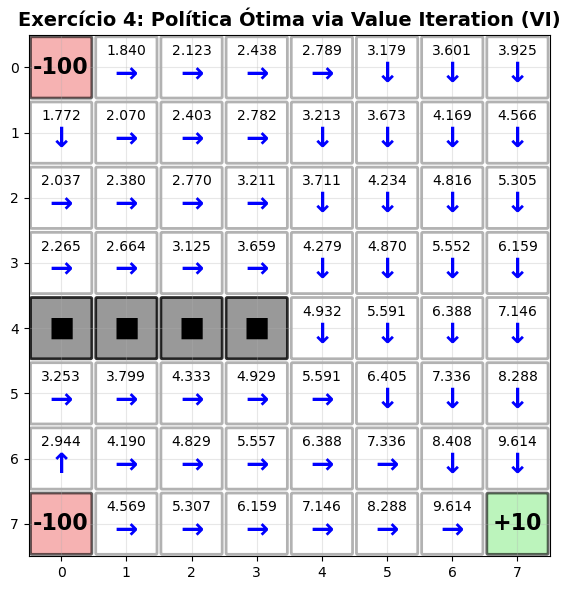

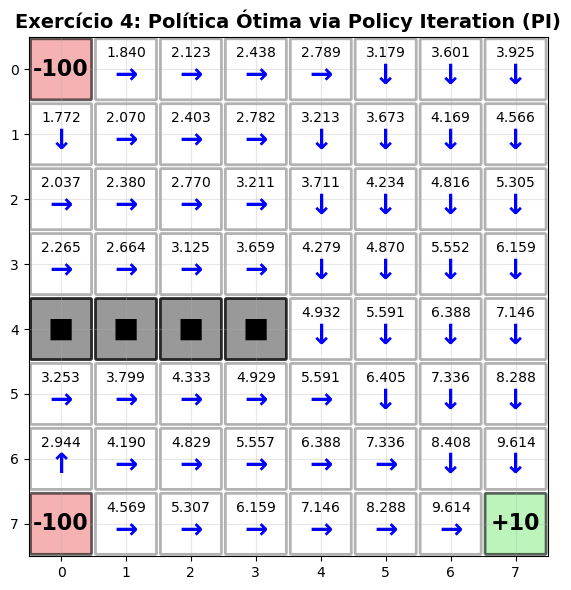

✓ COMPROVADO: As políticas geradas (as setas) são EXATAMENTE IGUAIS.


In [84]:
# ==========================================
# VISUALIZAÇÃO DAS POLÍTICAS LADO A LADO (OU EM SEQUÊNCIA)
# ==========================================

print("="*60)
print("COMPARAÇÃO VISUAL DAS POLÍTICAS ÓTIMAS")
print("="*60)

# Visualizando a Política Ótima encontrada pelo Value Iteration
visualize_gridworld(
    gw_ex4, 
    values=V_vi, 
    policy=pi_vi, 
    title="Exercício 4: Política Ótima via Value Iteration (VI)",
    figsize=(8, 6)
)
plt.show()

# Visualizando a Política Ótima encontrada pelo Policy Iteration
visualize_gridworld(
    gw_ex4, 
    values=V_pi, 
    policy=pi_pi, 
    title="Exercício 4: Política Ótima via Policy Iteration (PI)",
    figsize=(8, 6)
)
plt.show()

# Teste lógico para garantir que as políticas são estritamente iguais
politicas_iguais = np.array_equal(pi_vi, pi_pi)
if politicas_iguais:
    print("✓ COMPROVADO: As políticas geradas (as setas) são EXATAMENTE IGUAIS.")
else:
    print("⚠ AVISO: As políticas apresentam diferenças em alguns estados (geralmente ocorre quando há mais de uma ação ótima com o mesmo valor para um estado).")

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("ANÁLISE DE DIVERGÊNCIA NAS POLÍTICAS (VI vs PI)")
print("="*60)

# Identificando os índices (estados) onde as ações escolhidas são diferentes
diferencas_idx = np.where(pi_vi != pi_pi)[0]

if len(diferencas_idx) == 0:
    print("As políticas são 100% idênticas. Não há qualquer estado com divergência de ação.")
else:
    print(f"Foram encontradas divergências em {len(diferencas_idx)} estado(s).")
    print("Detalhe das divergências (Estado: [Ação VI] vs [Ação PI]):\n")
    
    # Criando uma matriz binária para o heatmap (1 = divergência, 0 = igualdade)
    mapa_divergencia = np.zeros(gw_ex4.nb_states)
    
    for idx in diferencas_idx:
        # Convertendo o índice 1D linear para coordenadas 2D (linha, coluna)
        row = idx // gw_ex4.cols
        col = idx % gw_ex4.cols
        estado = (row, col)
        
        # Mapeando o índice da ação para a string correspondente ('N', 'S', 'L', 'O')
        acao_vi = gw_ex4.actions[pi_vi[idx]]
        acao_pi = gw_ex4.actions[pi_pi[idx]]
        
        print(f"  -> Estado {estado}: Value Iteration escolheu '{acao_vi}' | Policy Iteration escolheu '{acao_pi}'")
        
        # Marcando o estado como divergente para o gráfico
        mapa_divergencia[idx] = 1
        
    # Visualizando as divergências no grid
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        mapa_divergencia.reshape((gw_ex4.rows, gw_ex4.cols)),
        cmap="Reds",         # Fundo branco (0) e células vermelhas (1)
        cbar=False,          # Removemos a barra de cores por ser binário
        linewidths=1, 
        linecolor='black',
        annot=False          # Sem números, apenas a cor para destacar a posição
    )
    plt.title("Mapa de Divergência de Políticas\n(A vermelho: estados onde VI e PI escolheram ações diferentes)")
    plt.xlabel("Colunas")
    plt.ylabel("Linhas")
    plt.show()

    print("\nNota Teórica para os Alunos:")
    print("Quando os algoritmos escolhem ações diferentes, mas o Valor Ótimo (V*) é o mesmo,")
    print("significa que há um 'empate matemático'. Ambas as ações levam a caminhos diferentes")
    print("que possuem exatamente a mesma utilidade final esperada. Ambos estão corretos!")

ANÁLISE DE DIVERGÊNCIA NAS POLÍTICAS (VI vs PI)
As políticas são 100% idênticas. Não há qualquer estado com divergência de ação.
